# Прогнозирование свойств композиционных материалов

Исследование для ВКР: анализ данных, предобработка, сравнение моделей, нейронная сеть и сохранение выбранных моделей для локального приложения.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.base import clone
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from itertools import combinations
from IPython.display import display

In [3]:
bp = pd.read_excel("X_bp.xlsx", index_col=0)
nup = pd.read_excel("X_nup.xlsx", index_col=0)
print(bp.shape, nup.shape)
bp.head()

(1023, 10) (1040, 3)


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2"
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0


In [4]:
print(bp.index[:5])
print(nup.index[:5])

Index([0, 1, 2, 3, 4], dtype='int64')
Index([0, 1, 2, 3, 4], dtype='int64')


In [5]:
df = bp.join(nup, how="inner")
print(df.shape)
df.columns.tolist()

(1023, 13)


['Соотношение матрица-наполнитель',
 'Плотность, кг/м3',
 'модуль упругости, ГПа',
 'Количество отвердителя, м.%',
 'Содержание эпоксидных групп,%_2',
 'Температура вспышки, С_2',
 'Поверхностная плотность, г/м2',
 'Модуль упругости при растяжении, ГПа',
 'Прочность при растяжении, МПа',
 'Потребление смолы, г/м2',
 'Угол нашивки, град',
 'Шаг нашивки',
 'Плотность нашивки']

Выше мы выполнили склейку двух таблиц предоставленных в задании. У нас получилось 1023 строки т.к. в таблице X_nup было 1040 строк, а в таблице X_bp 1023, при INNER строки которые не имеют такого же индекса в X_bp таблице, не попадали в итоговый вариант.

In [6]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки           

Соотношение матрица-наполнитель         0
Плотность, кг/м3                        0
модуль упругости, ГПа                   0
Количество отвердителя, м.%             0
Содержание эпоксидных групп,%_2         0
Температура вспышки, С_2                0
Поверхностная плотность, г/м2           0
Модуль упругости при растяжении, ГПа    0
Прочность при растяжении, МПа           0
Потребление смолы, г/м2                 0
Угол нашивки, град                      0
Шаг нашивки                             0
Плотность нашивки                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

Мы проверили, что пропусков и дублей нет.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Соотношение матрица-наполнитель,1023.0,2.930366,0.913222,0.389403,2.317887,2.906878,3.552660,5.591742
"Плотность, кг/м3",1023.0,1975.734888,73.729231,1731.764635,1924.155467,1977.621657,2021.374375,2207.773481
"модуль упругости, ГПа",1023.0,739.923233,330.231581,2.436909,500.047452,739.664328,961.812526,1911.536477
"Количество отвердителя, м.%",1023.0,110.570769,28.295911,17.740275,92.443497,110.564840,129.730366,198.953207
"Содержание эпоксидных групп,%_2",1023.0,22.244390,2.406301,14.254985,20.608034,22.230744,23.961934,33.000000
"Температура вспышки, С_2",1023.0,285.882151,40.943260,100.000000,259.066528,285.896812,313.002106,413.273418
"Поверхностная плотность, г/м2",1023.0,482.731833,281.314690,0.603740,266.816645,451.864365,693.225017,1399.542362
"Модуль упругости при растяжении, ГПа",1023.0,73.328571,3.118983,64.054061,71.245018,73.268805,75.356612,82.682051
"Прочность при растяжении, МПа",1023.0,2466.922843,485.628006,1036.856605,2135.850448,2459.524526,2767.193119,3848.436732
"Потребление смолы, г/м2",1023.0,218.423144,59.735931,33.803026,179.627520,219.198882,257.481724,414.590628


У модуля упругости минимум около 2.4 при среднем около 740, у поверхностной плотности минимум около 0.6 при среднем около 483. Эти значения заметно отличаются от основной части данных, но не выходят за границы IQR.

У шага и плотности нашивки встречаются нулевые значения. По имеющемуся описанию нельзя установить, являются ли отмеченные значения ошибками измерения, поэтому вручную их не заменяем. При обучении используем описанное ниже правило IQR.

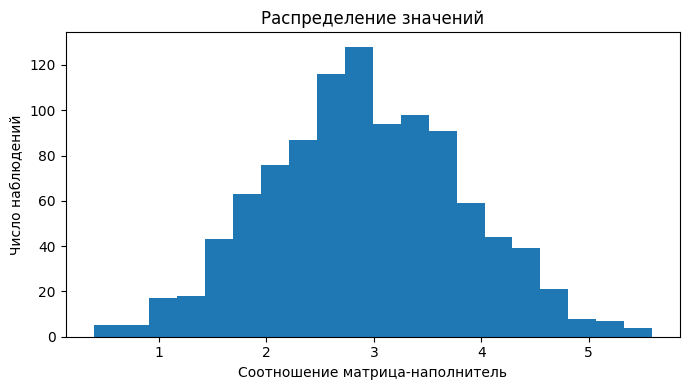

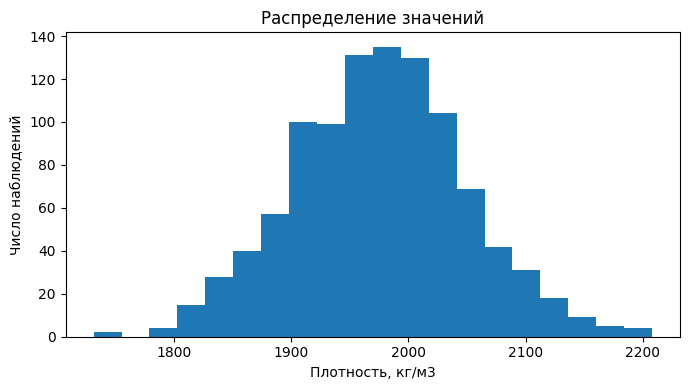

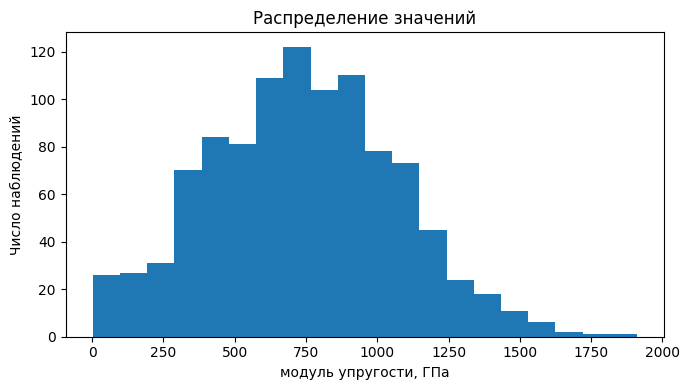

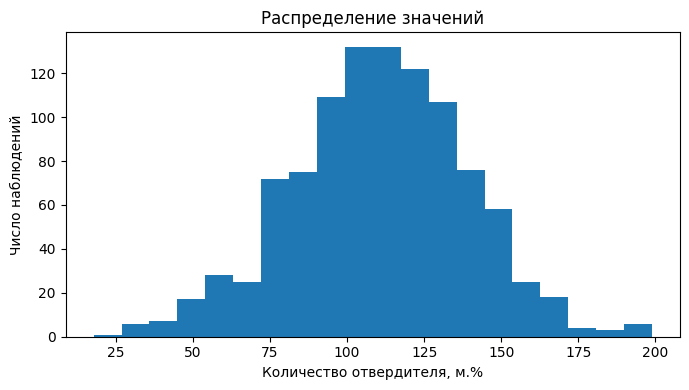

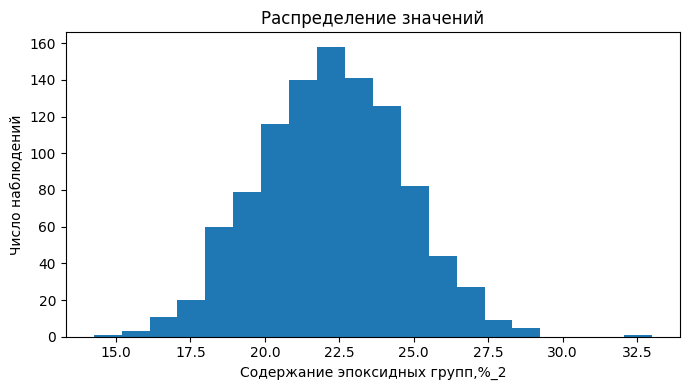

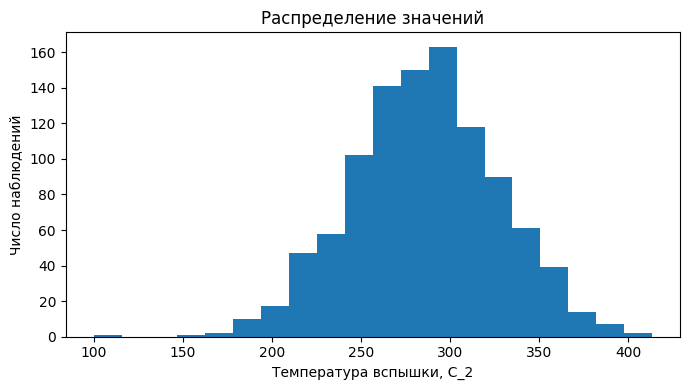

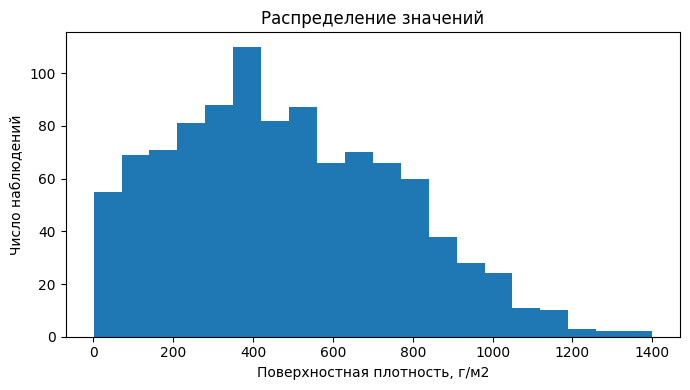

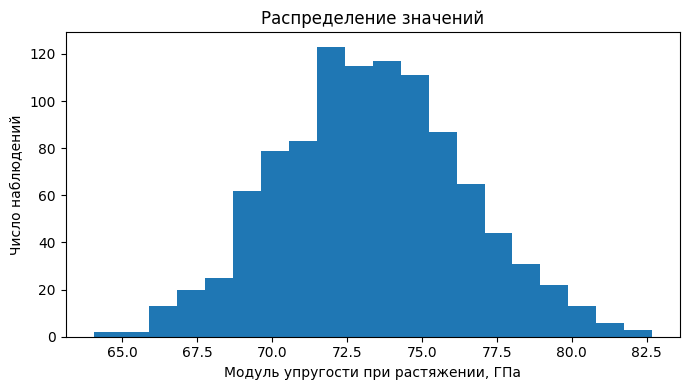

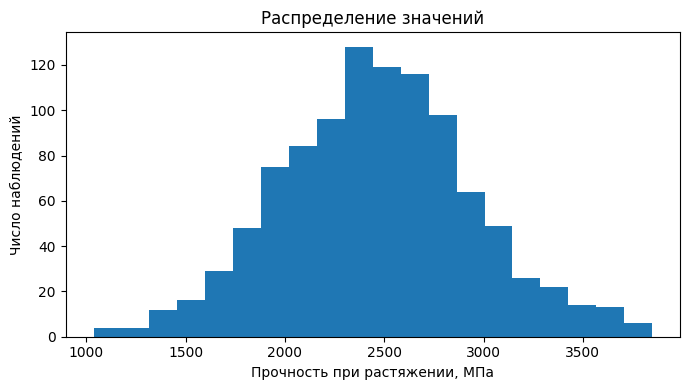

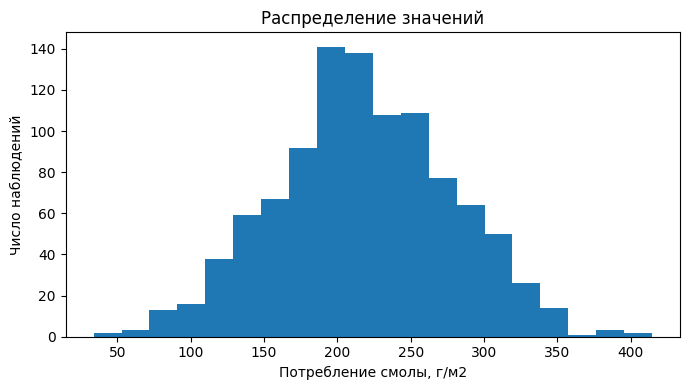

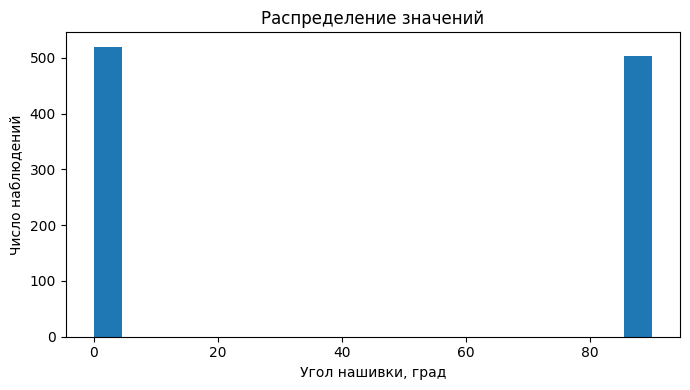

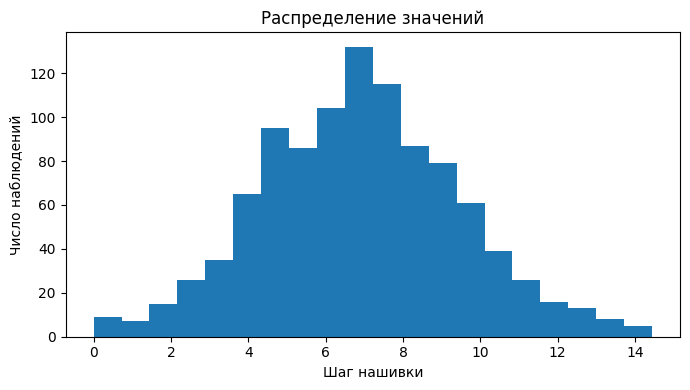

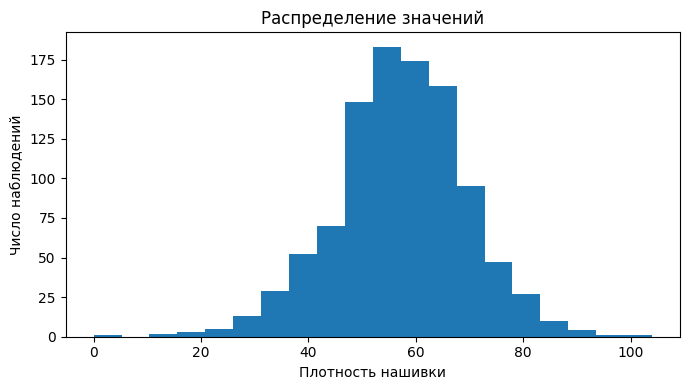

In [9]:
for col in df.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=20)
    plt.xlabel(col)
    plt.ylabel("Число наблюдений")
    plt.title("Распределение значений")
    plt.tight_layout()
    plt.show()
    plt.close()

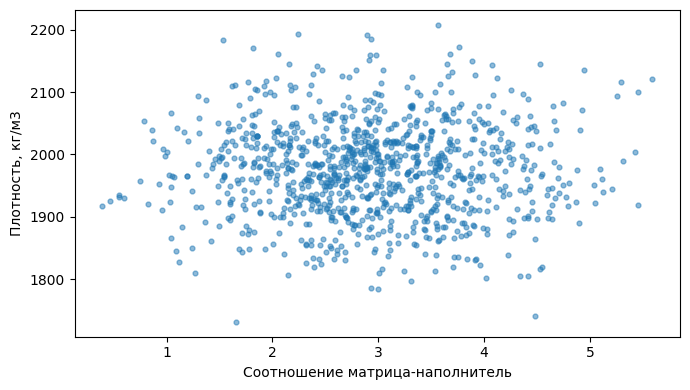

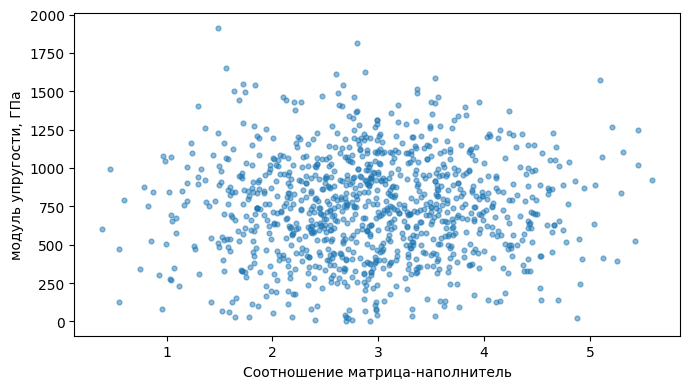

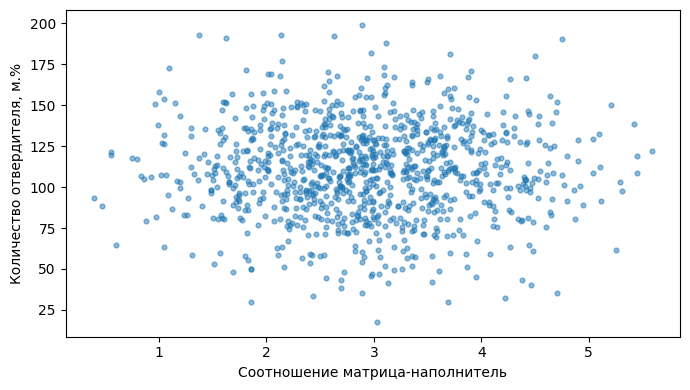

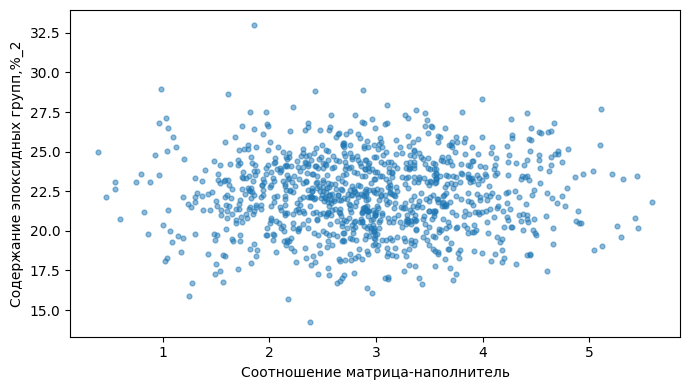

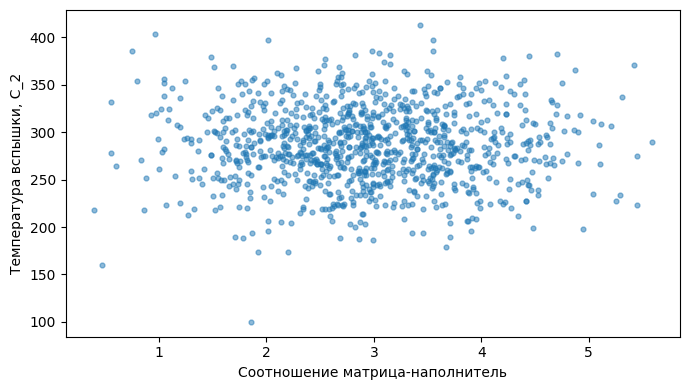

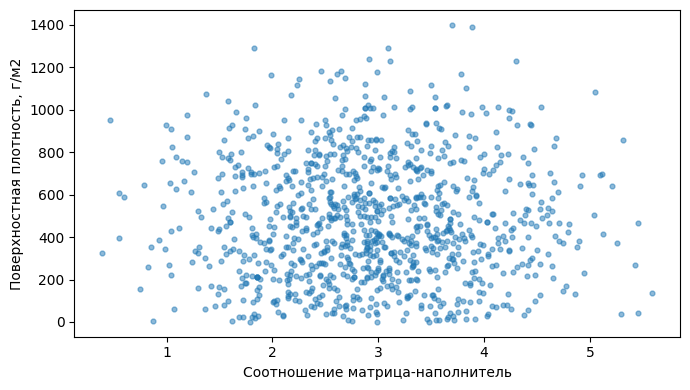

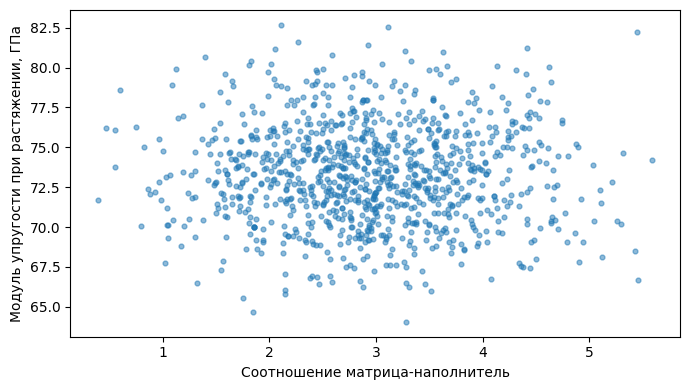

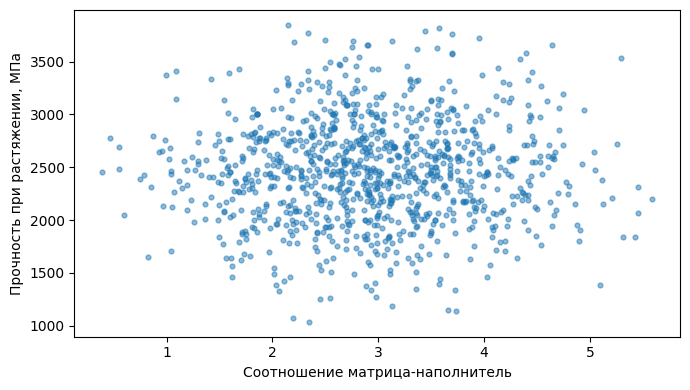

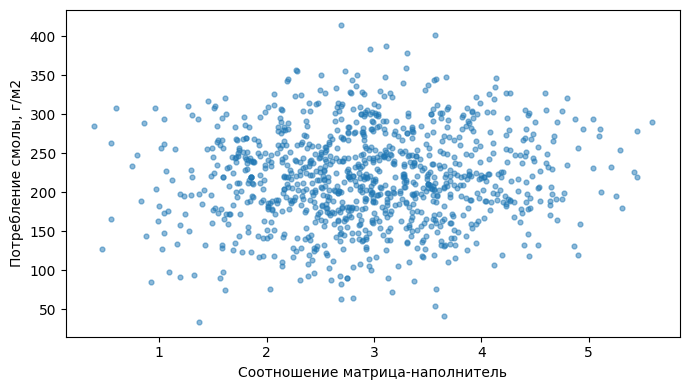

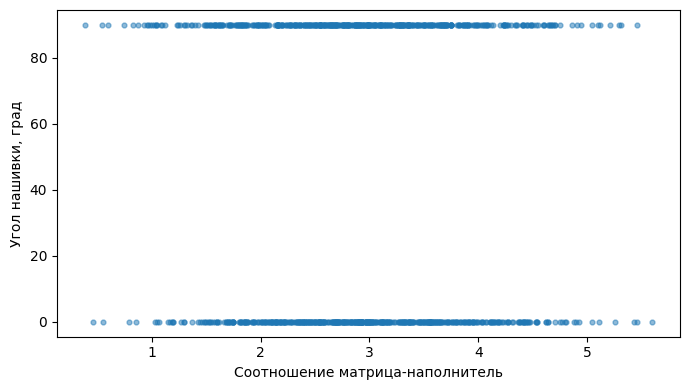

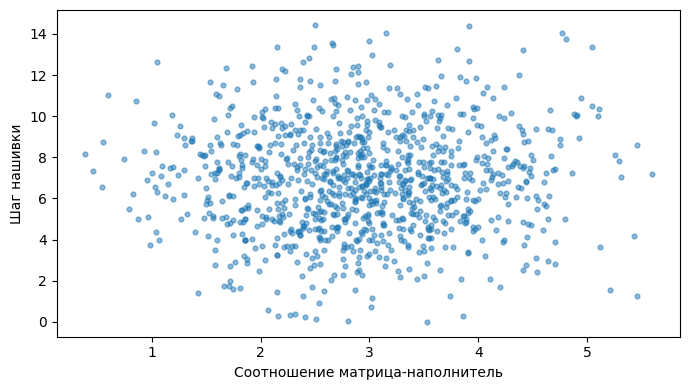

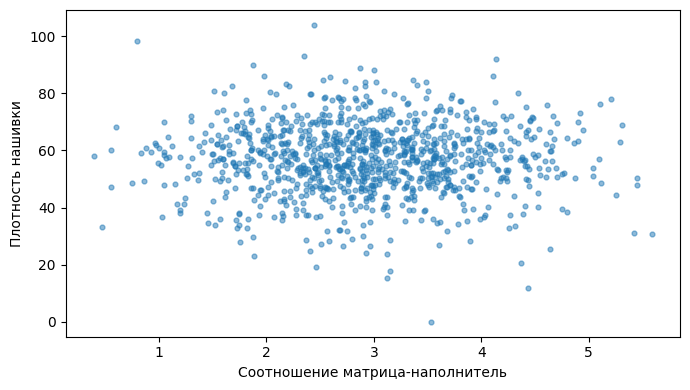

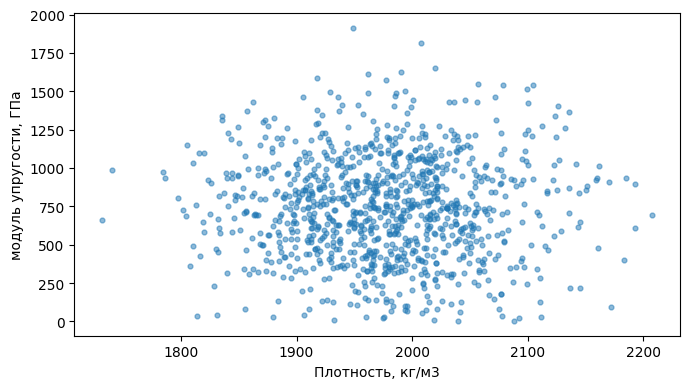

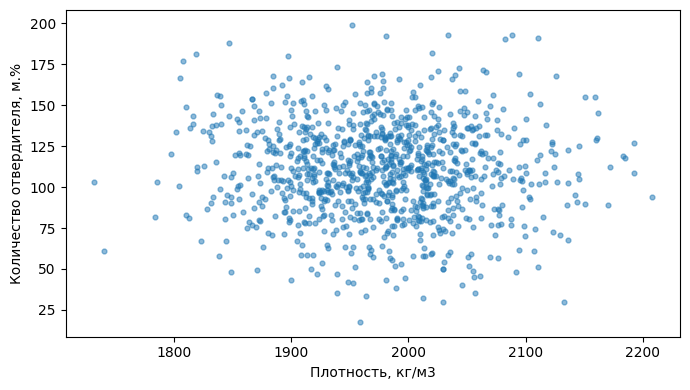

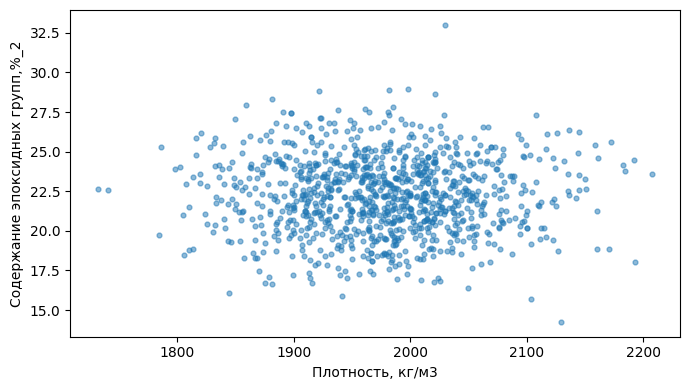

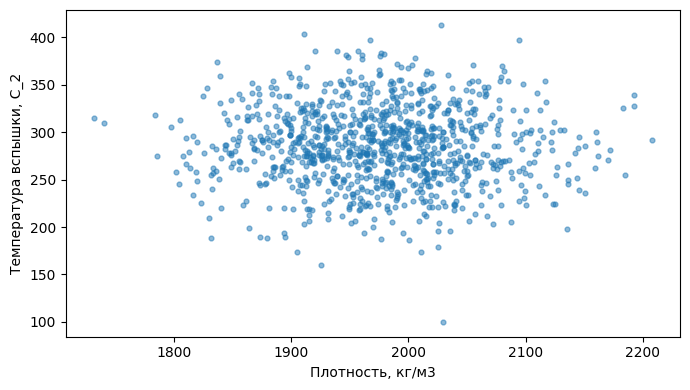

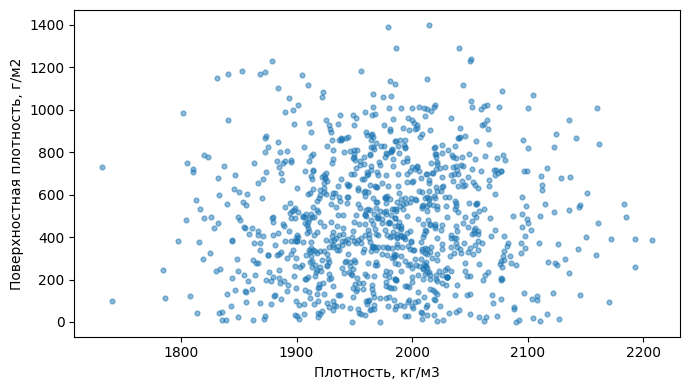

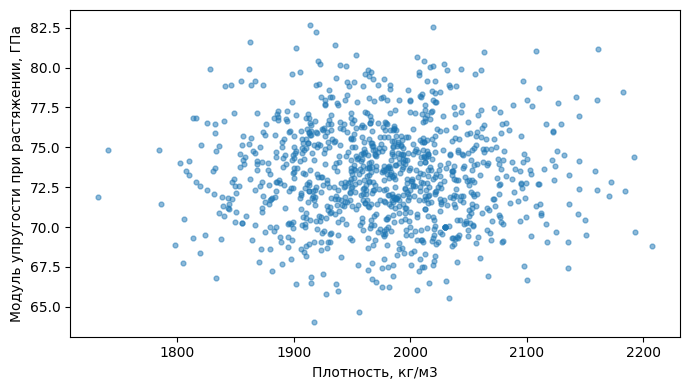

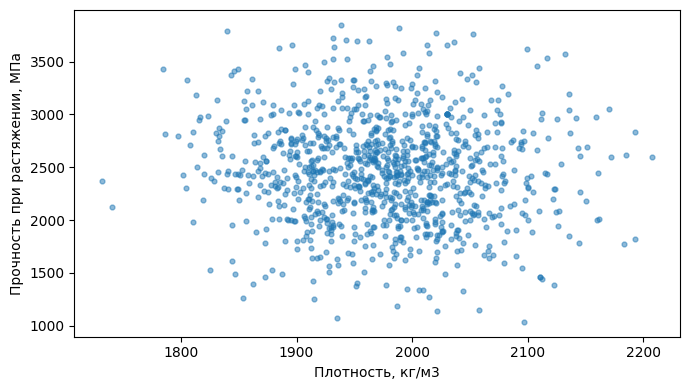

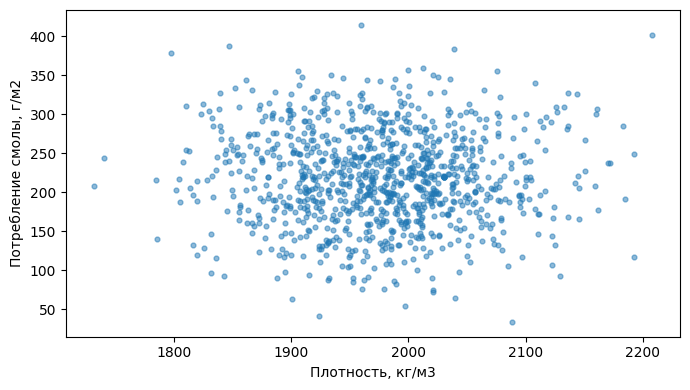

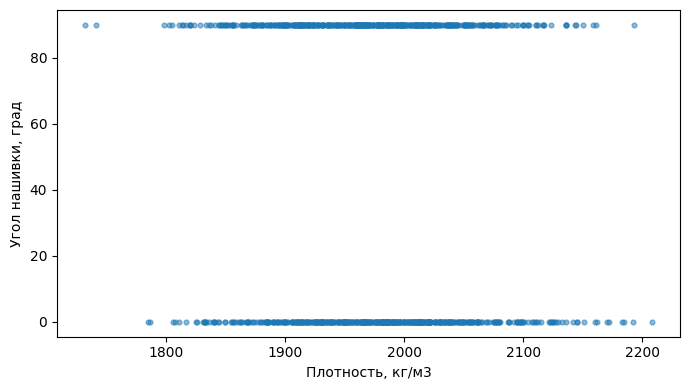

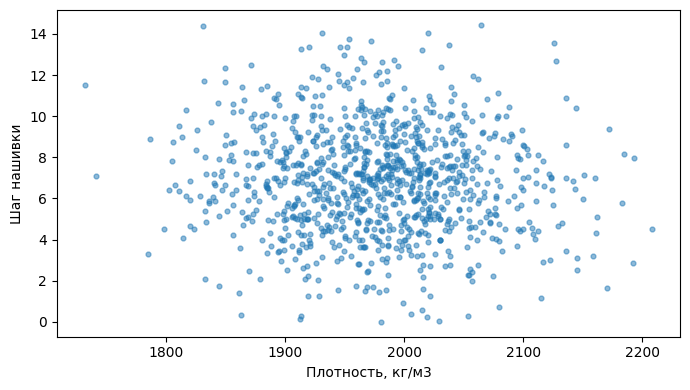

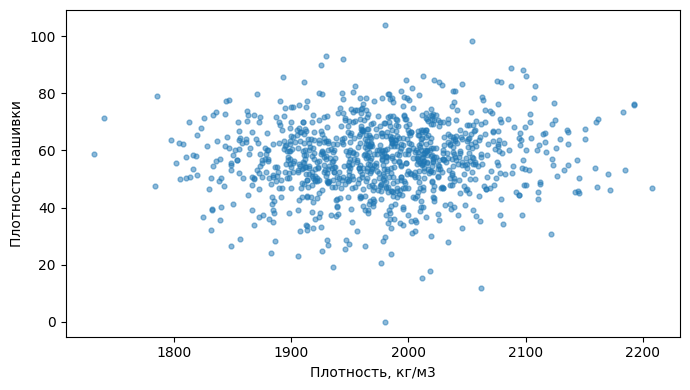

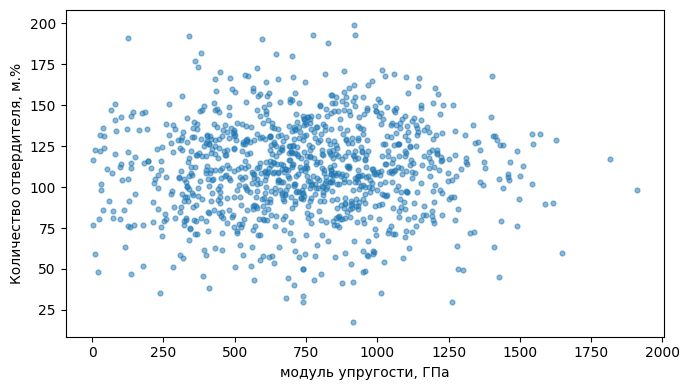

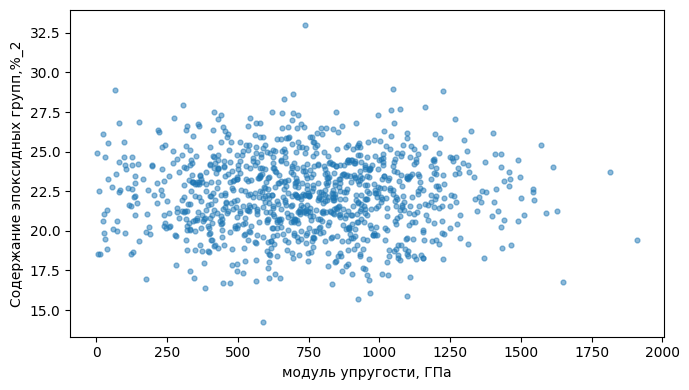

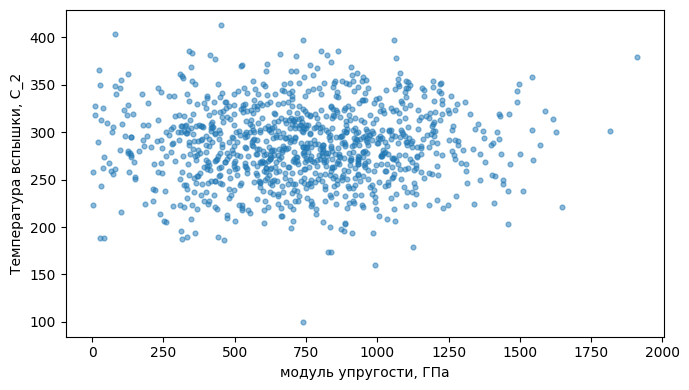

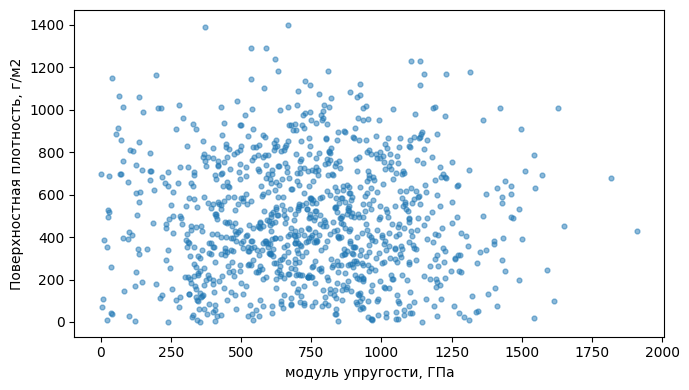

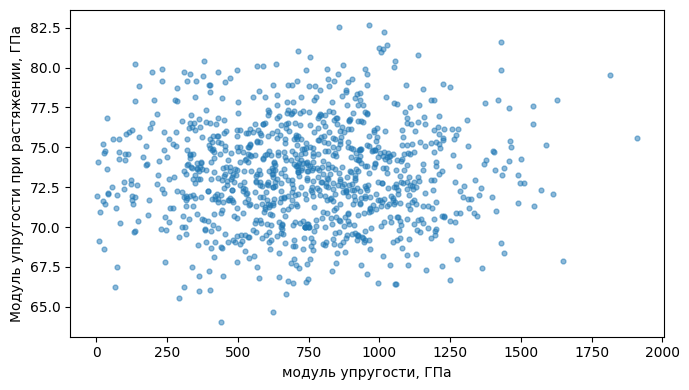

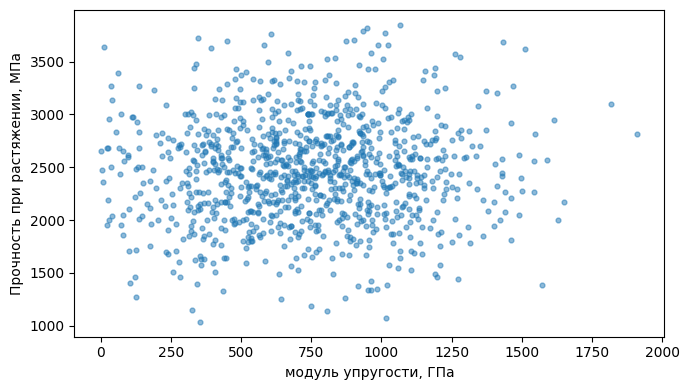

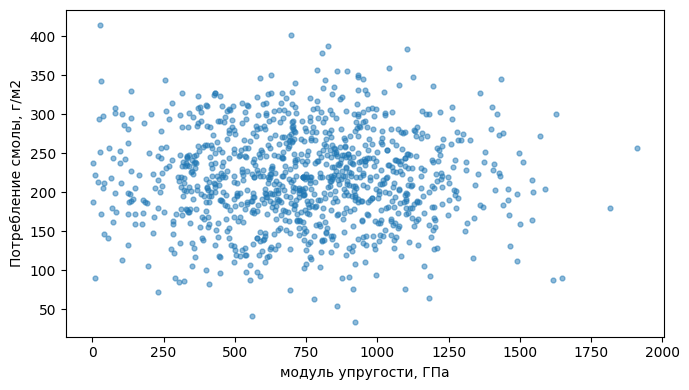

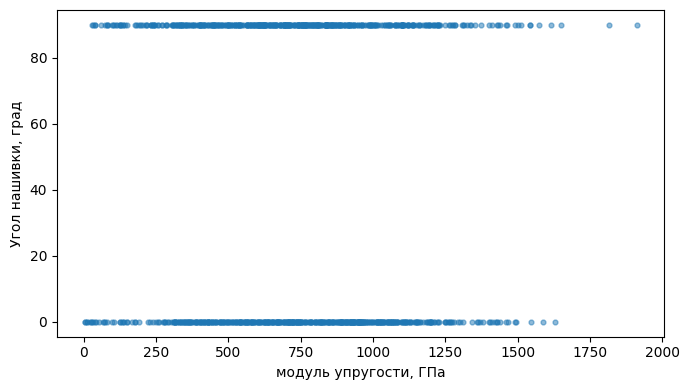

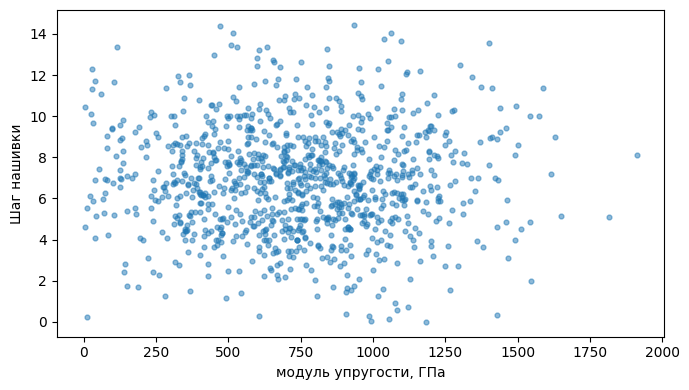

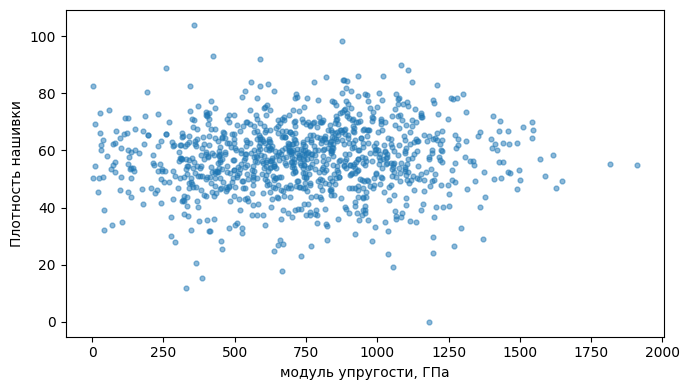

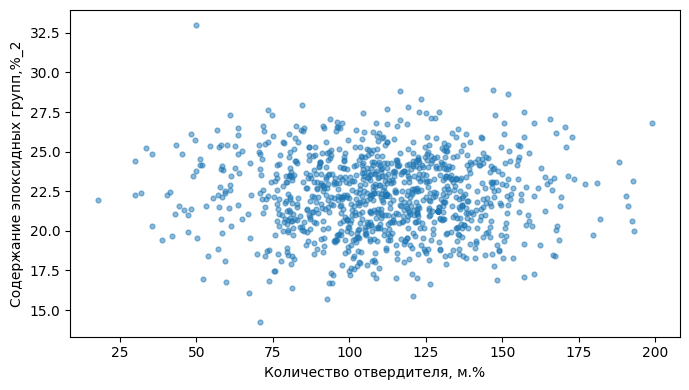

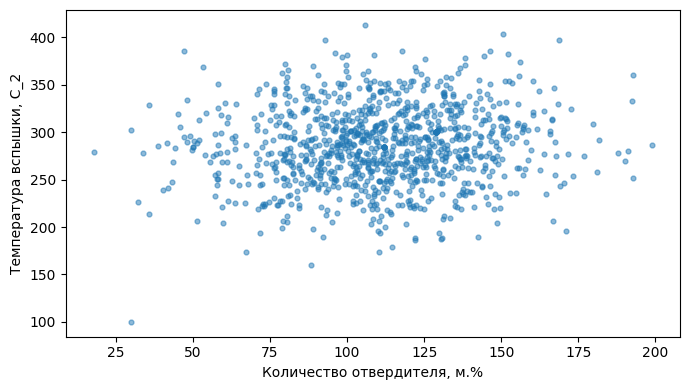

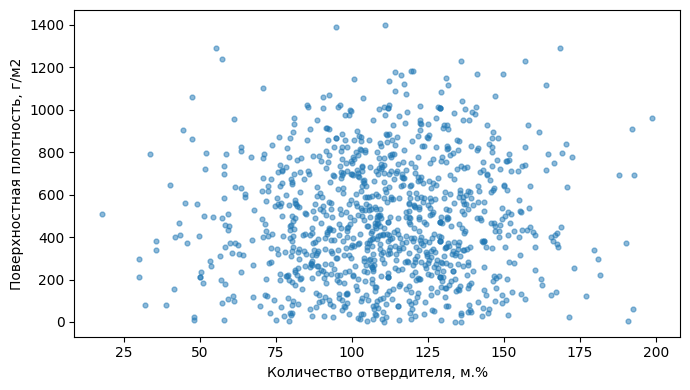

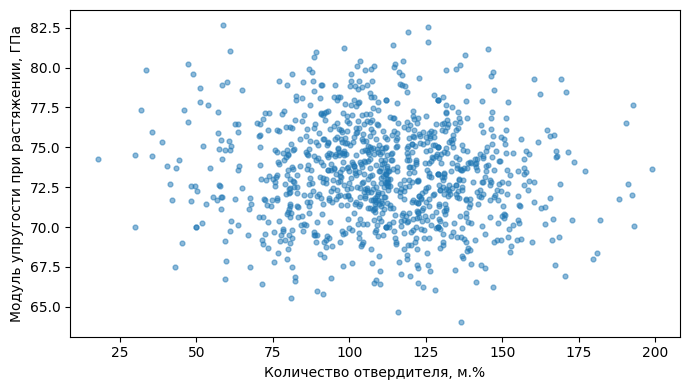

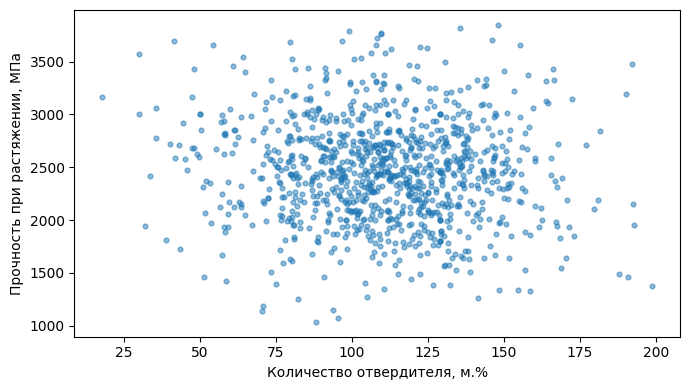

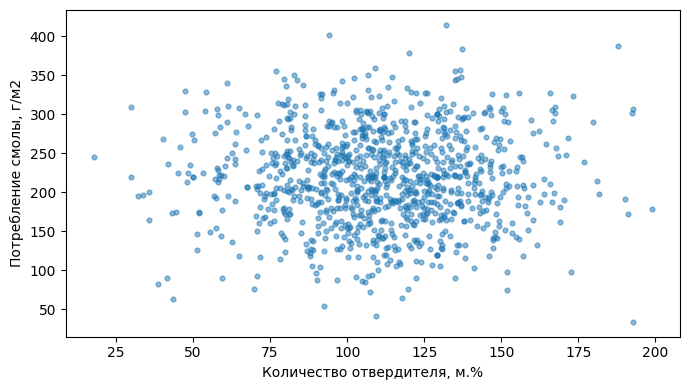

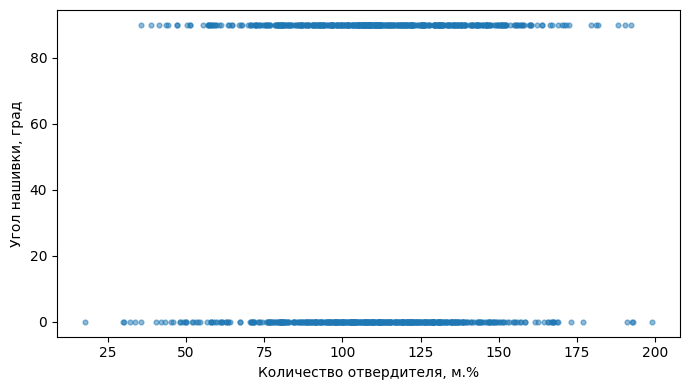

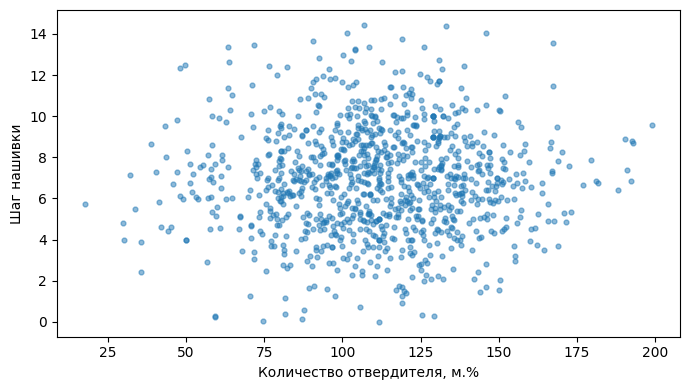

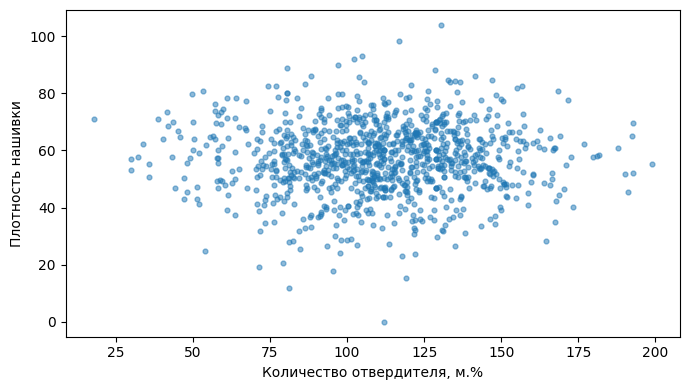

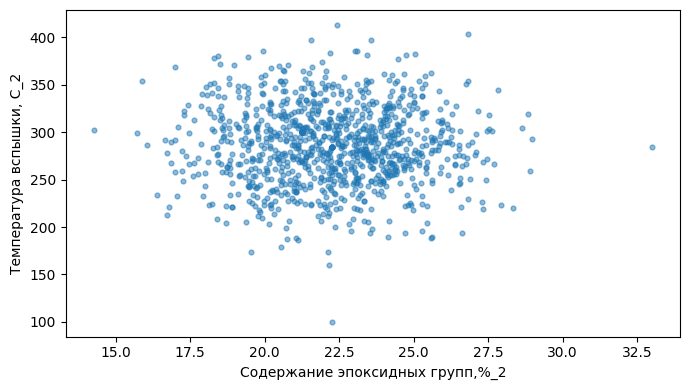

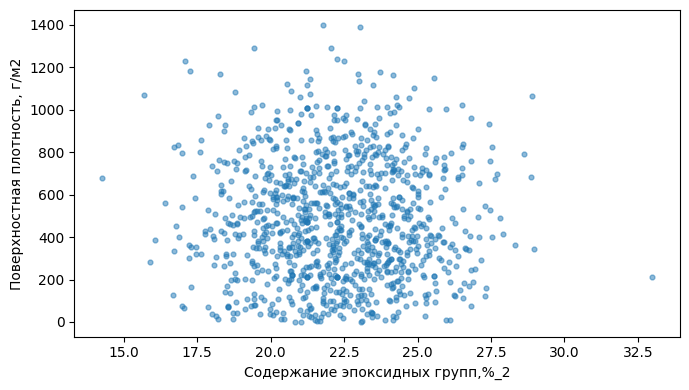

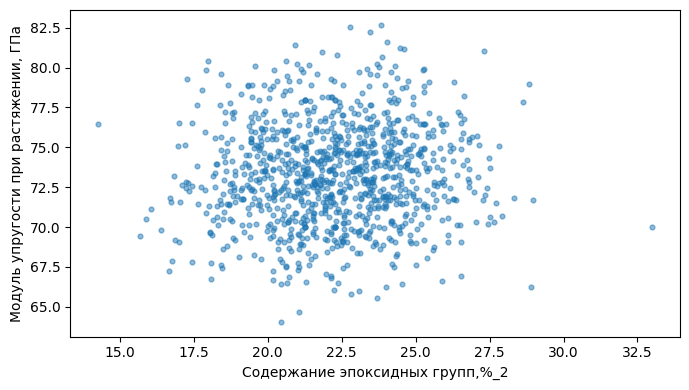

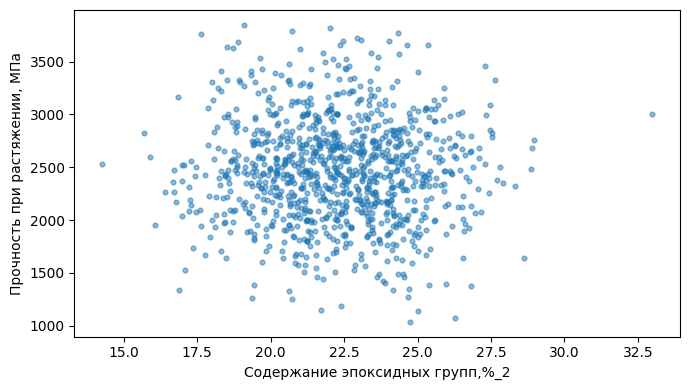

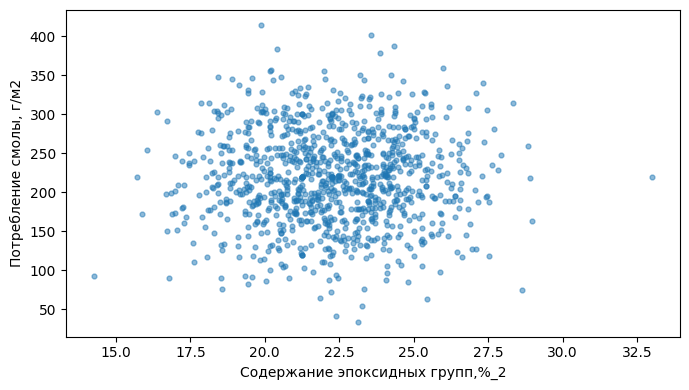

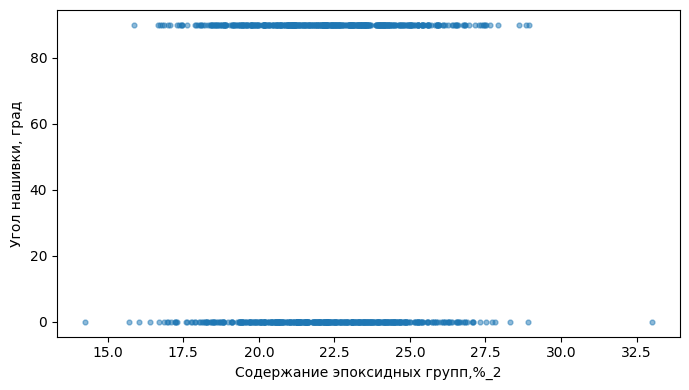

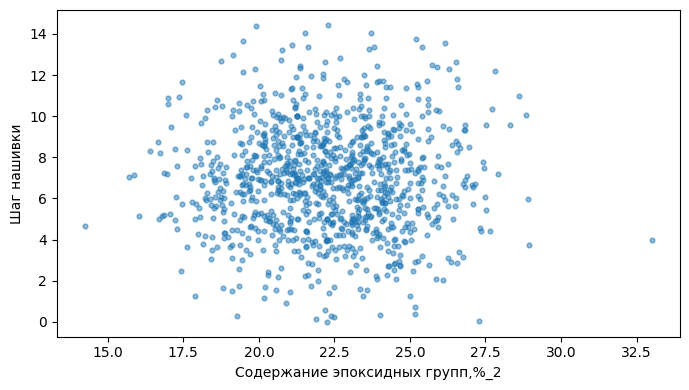

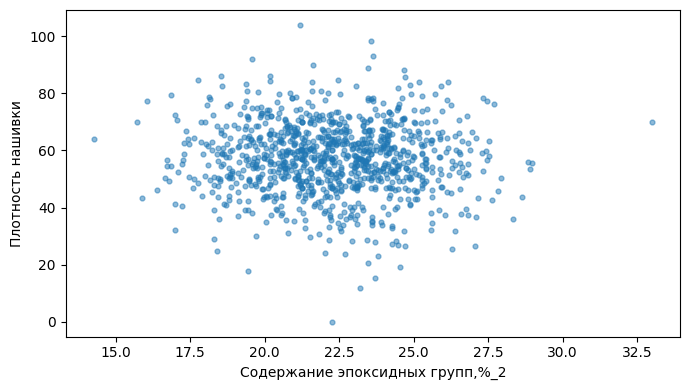

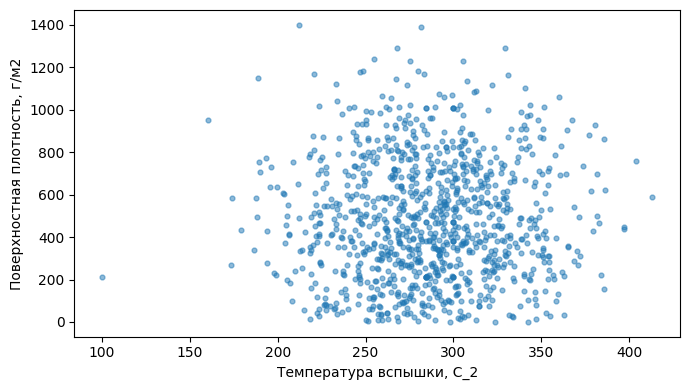

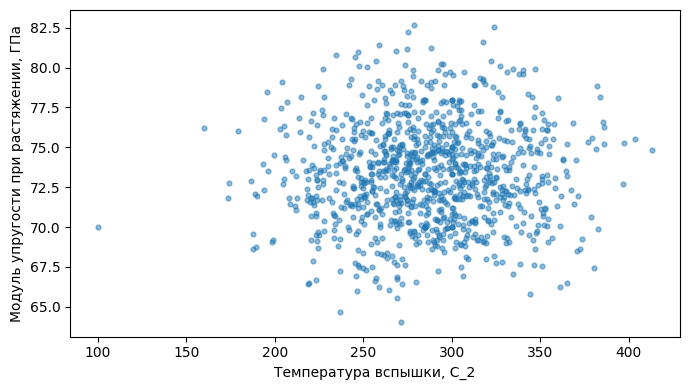

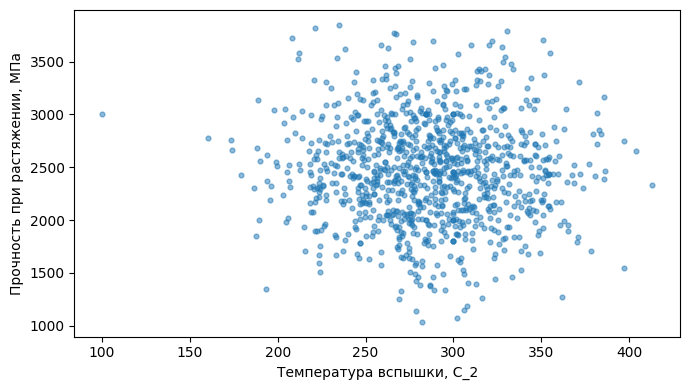

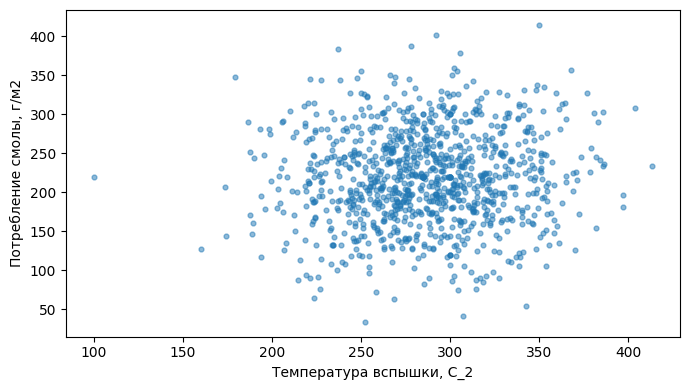

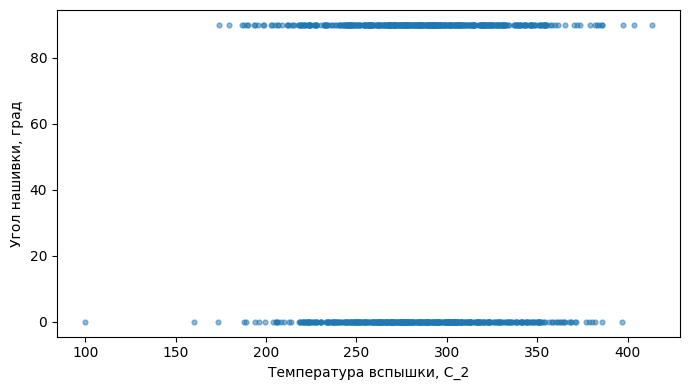

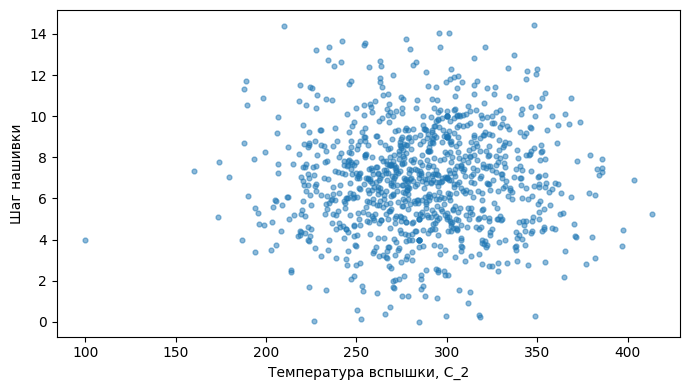

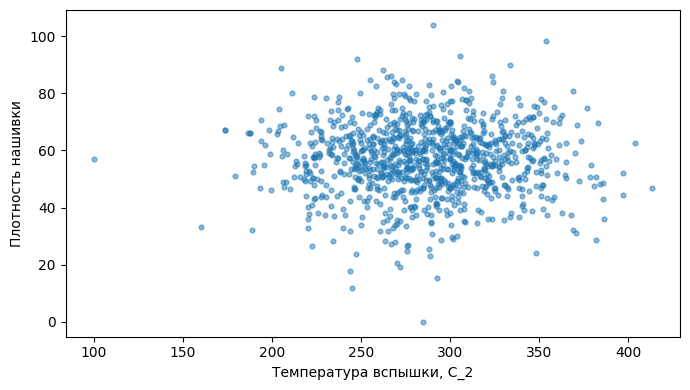

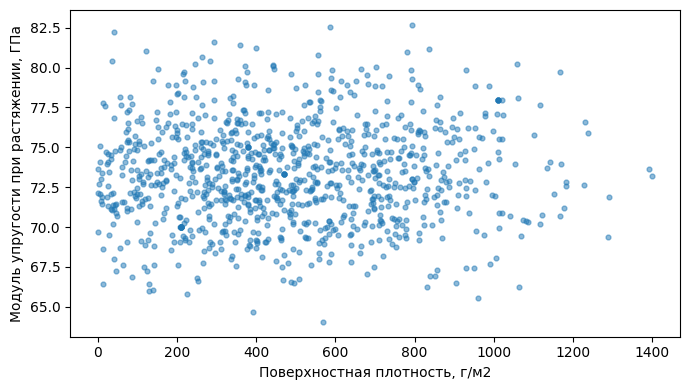

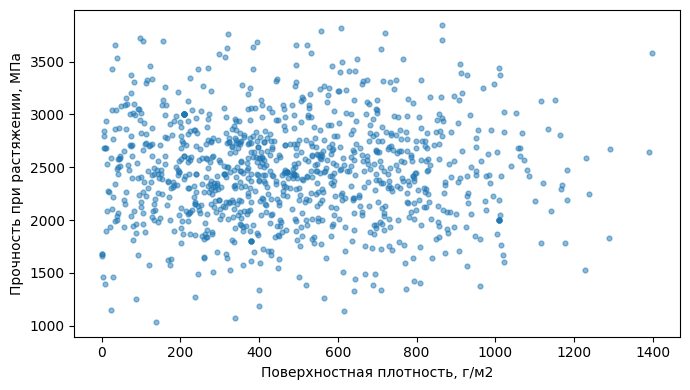

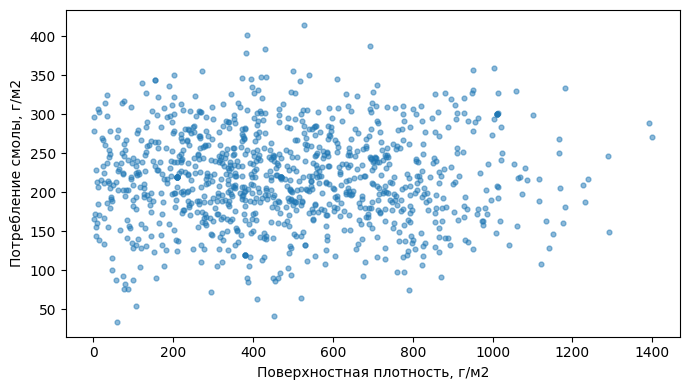

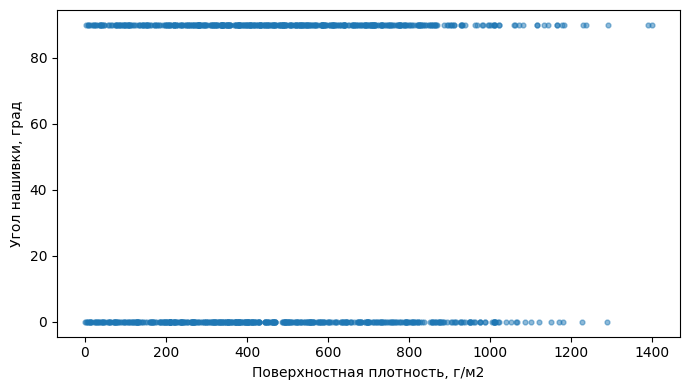

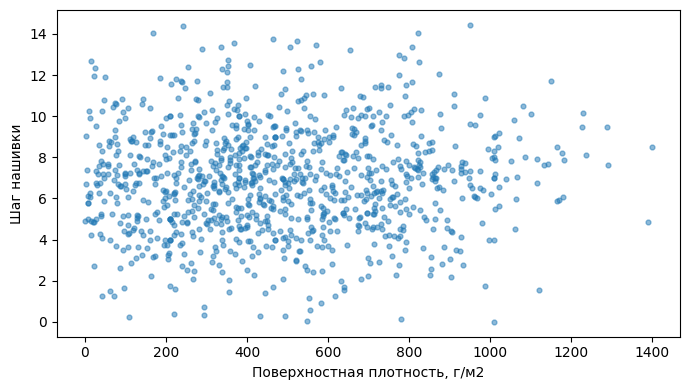

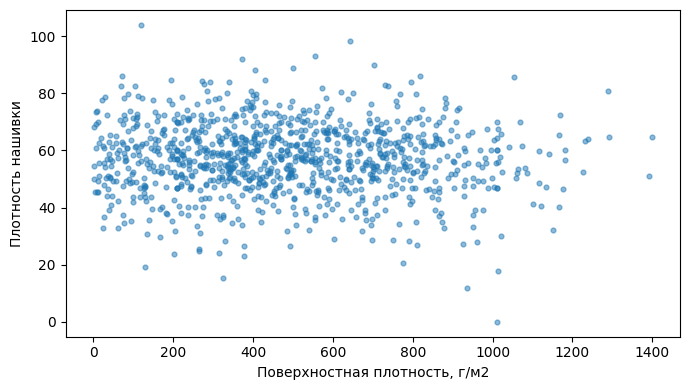

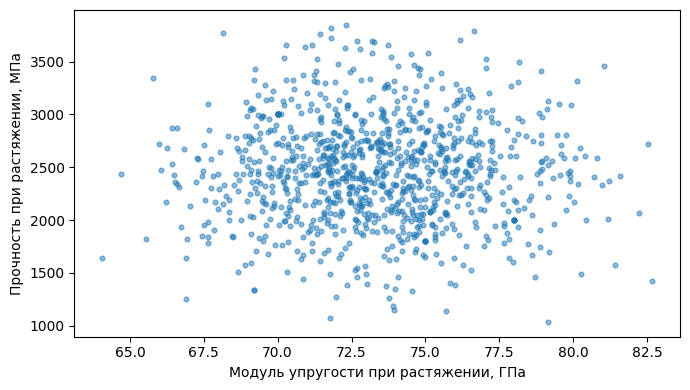

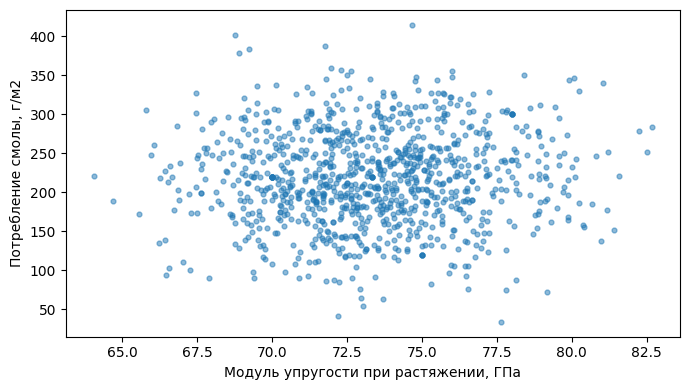

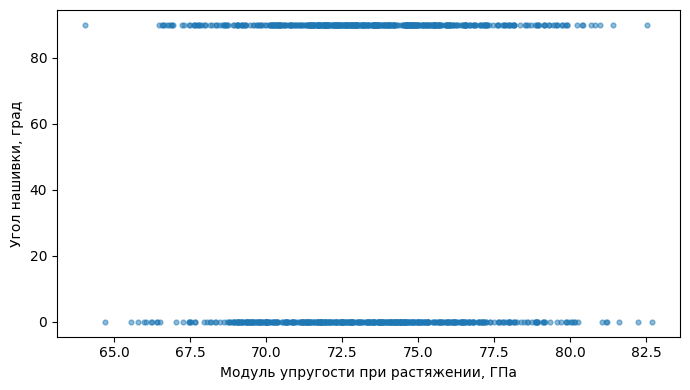

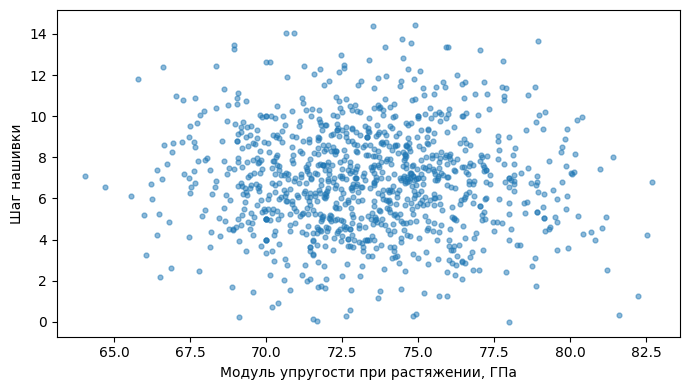

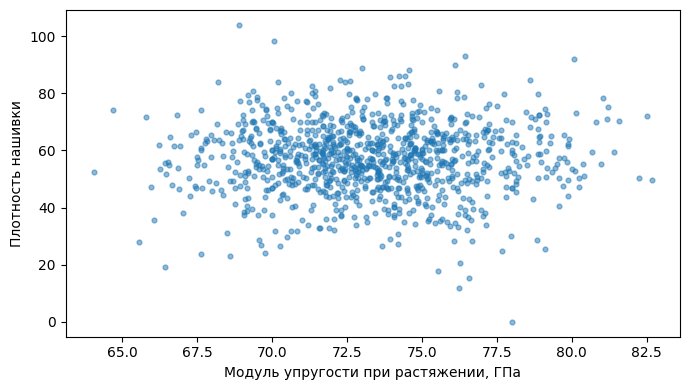

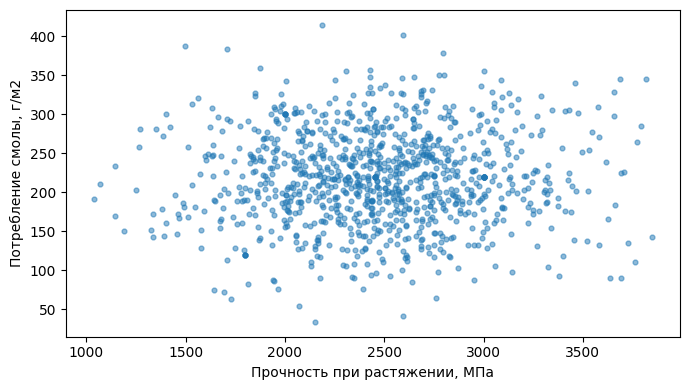

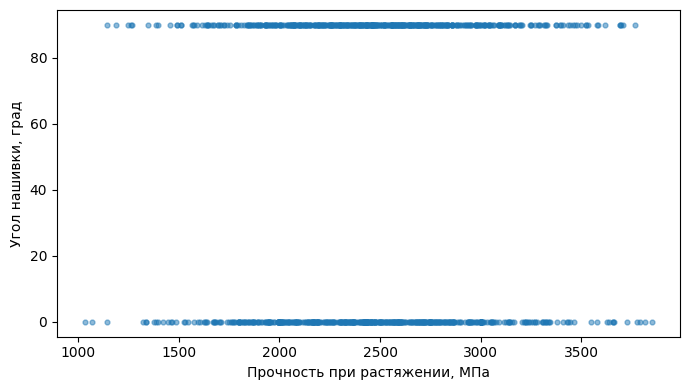

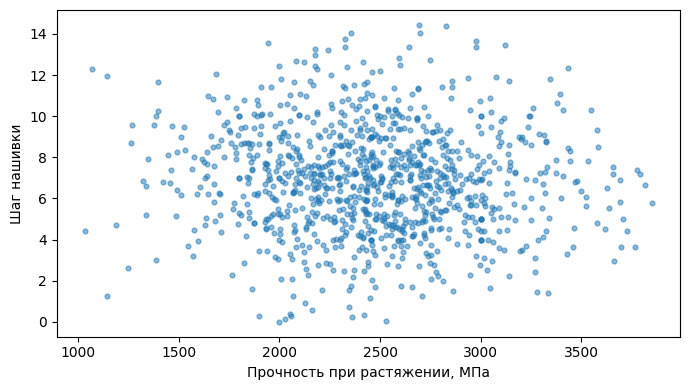

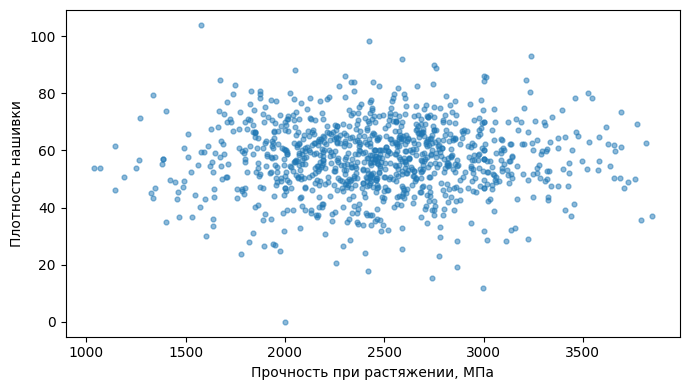

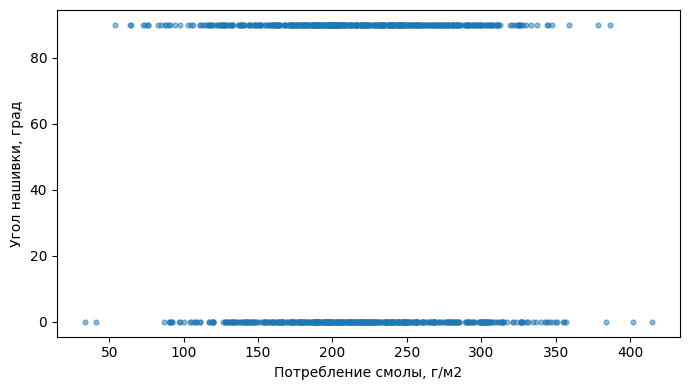

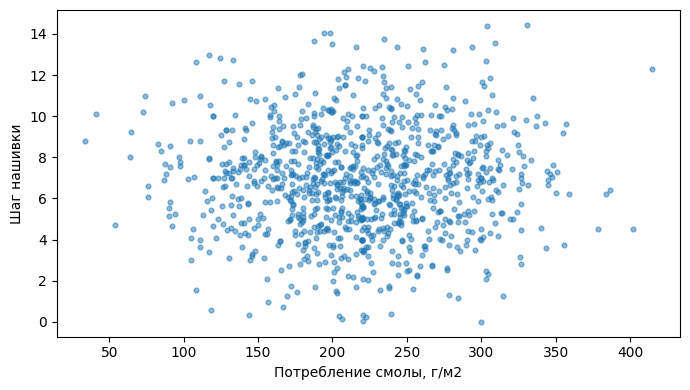

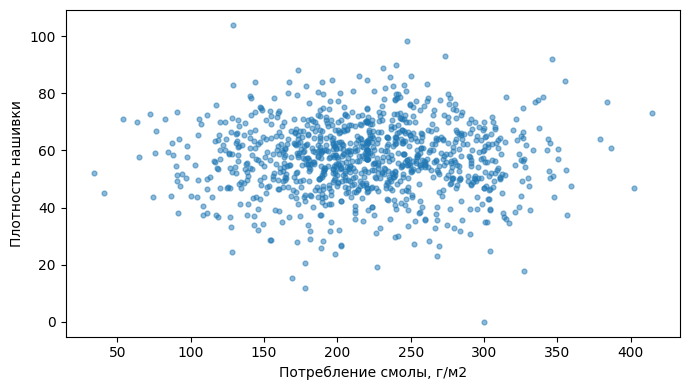

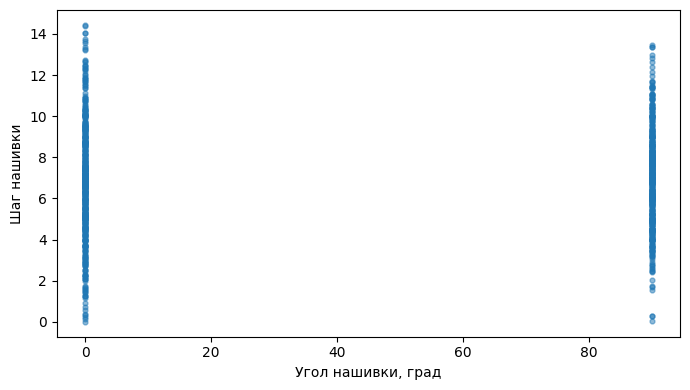

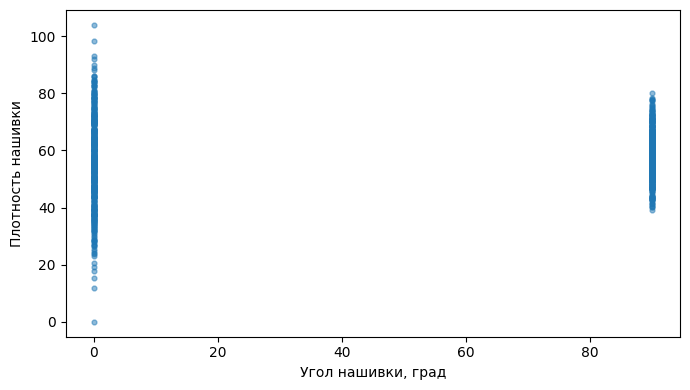

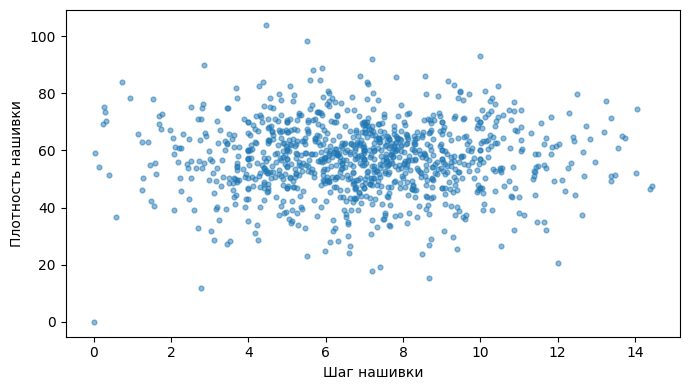

In [10]:
for left, right in combinations(df.columns, 2):
    plt.figure(figsize=(7, 4))
    plt.scatter(df[left], df[right], s=12, alpha=0.5)
    plt.xlabel(left)
    plt.ylabel(right)
    plt.tight_layout()
    plt.show()
    plt.close()

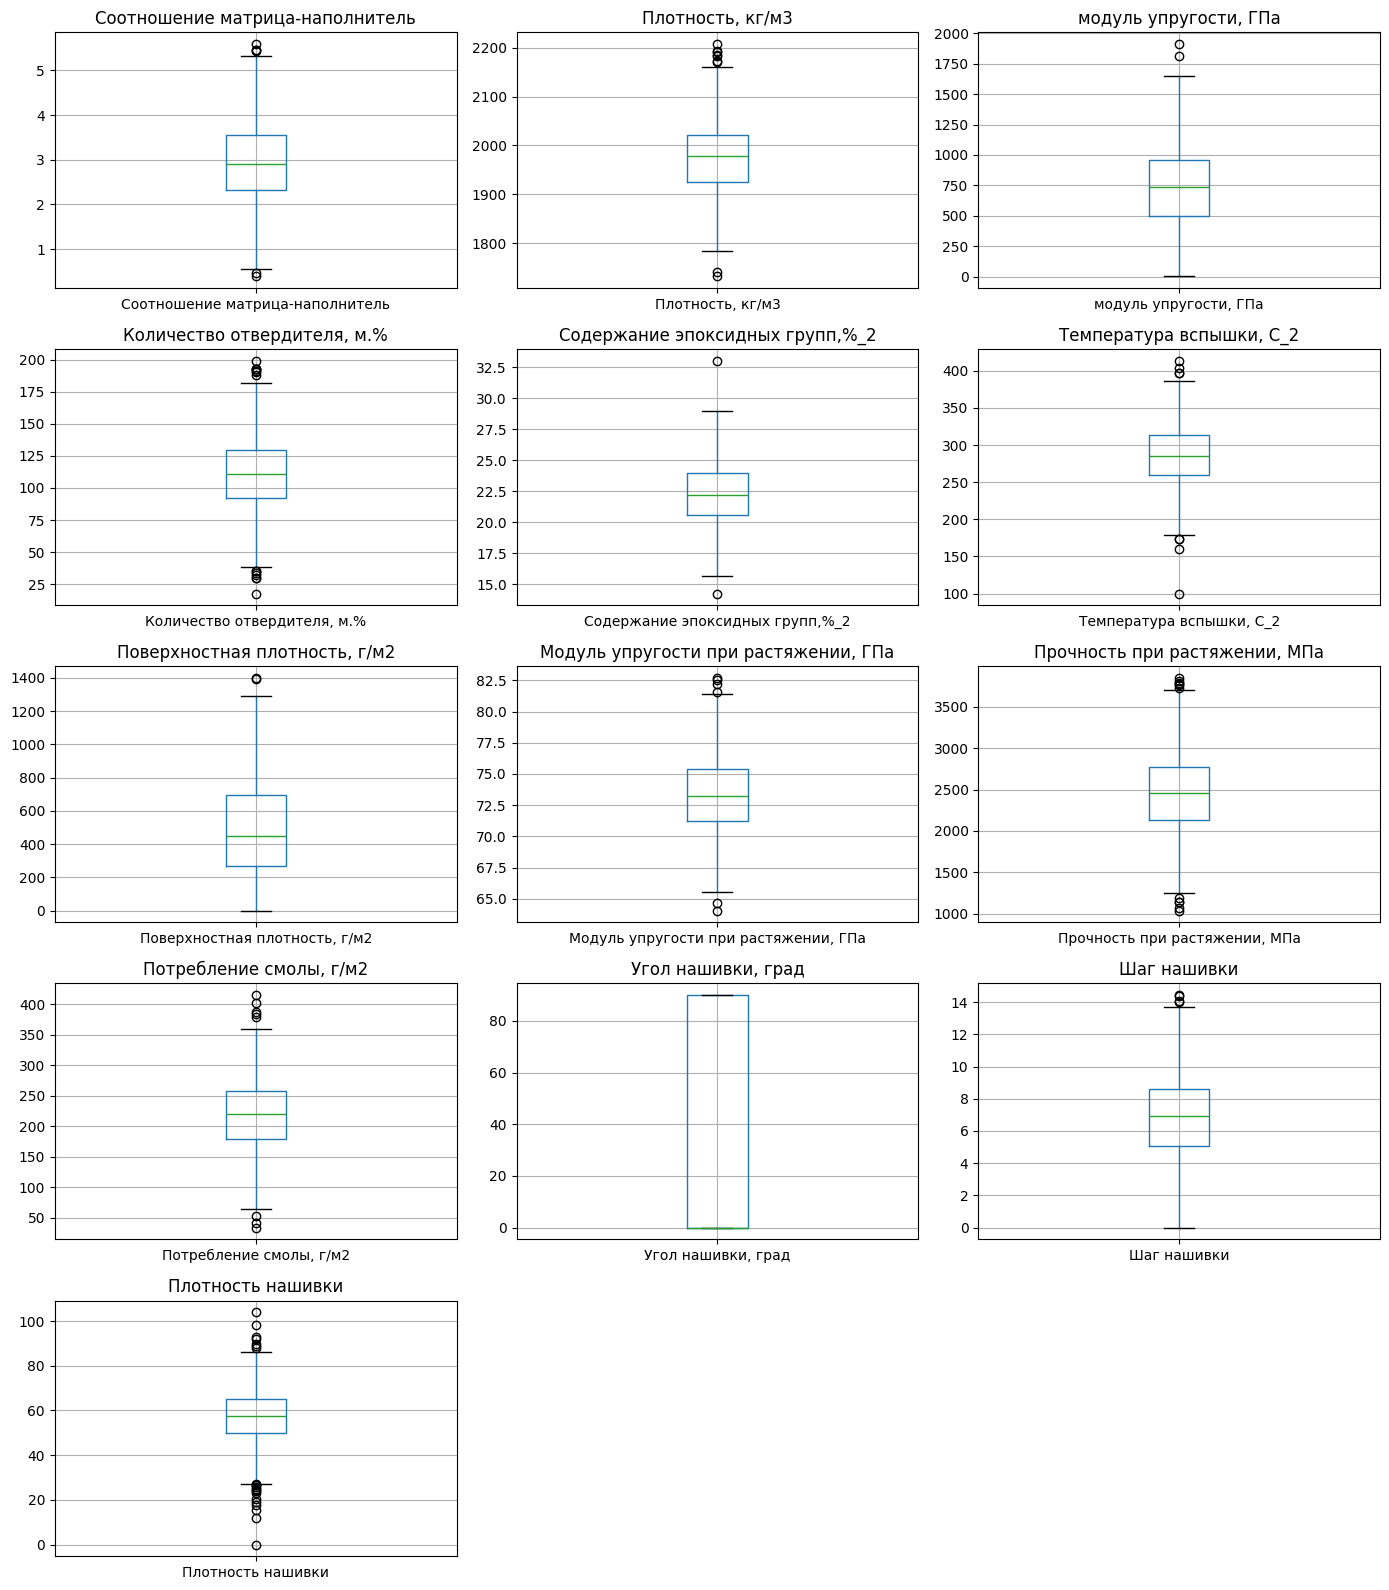

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(df.columns), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Соотношение матрица–наполнитель
Выбросы с обеих сторон усов (примерно 0.39 снизу и 5.6 сверху). Медиана почти по центру межквартильного диапазона, лёгкий сдвиг к первому квартилю. Ящик узкий относительно усов. Центральные 50% значений находятся примерно в диапазоне 2.3–3.6.

Плотность, кг/м³
Выбросы с обеих сторон усов (несколько точек у 1730 и у 2200). Ящик компактный, медиана по центру - распределение почти симметричное. 

модуль упругости, ГПа 
По правилу IQR выбросы отмечены только сверху. Нижний ус уходит почти к нулю. Из‑за верхних точек ось растянута, ящик кажется прижатым вниз. Разброс большой.

Количество отвердителя, м.%
Выбросы с обеих сторон усов. Медиана по центру ящика. Усы длинные, но форма близка к симметричной.

Содержание эпоксидных групп, %
По одной точке за каждым усом (примерно 14.3 снизу, сверху 33). Ящик короткий: большая часть значений в узком коридоре.

Температура вспышки, °C
Выбросы с обеих сторон усов (сверху кучка около 400, снизу несколько точек и одна около 100). Медиана по центру. Точка 100 выделяется сильнее остальных.

Поверхностная плотность, г/м²
Выбросы сверху (1300–1400). Снизу ус почти до нуля, min ≈ 0.6 — на усе. Медиана чуть ближе к первому квартилю, верхний ус длиннее нижнего.

Модуль упругости при растяжении, ГПа (цель)
Выбросы с обеих сторон усов. Ящик очень узкий (примерно 71–75 при среднем ≈ 73).

Прочность при растяжении, МПа (цель)
Выбросы с обеих сторон усов (низ ≈ 1000–1200, верх ≈ 3800). Медиана по центру. Шкала широкая.

Потребление смолы, г/м²
Выбросы с обеих сторон усов. Медиана по центру, ящик симметричный. Min ≈ 34 при среднем ≈ 218. Нижние значения заметно отличаются от основной массы, но по этому графику нельзя определить, являются ли они ошибками.

Угол нашивки, град
Выбросов нет. Угол принимает только два значения: 0 и 90 градусов, поэтому ящик растянут между ними.

Шаг нашивки
Выбросы сверху (14). Нижний ус на 0. Медиана по центру. 

Плотность нашивки
Выбросы с обеих сторон усов.

In [12]:
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = (df < lower) | (df > upper)

print(outliers.sum())          # сколько выбросов в каждом столбце
print(outliers.any(axis=1).sum())  # сколько строк заденет хотя бы один выброс

Соотношение матрица-наполнитель          6
Плотность, кг/м3                         9
модуль упругости, ГПа                    2
Количество отвердителя, м.%             14
Содержание эпоксидных групп,%_2          2
Температура вспышки, С_2                 8
Поверхностная плотность, г/м2            2
Модуль упругости при растяжении, ГПа     6
Прочность при растяжении, МПа           11
Потребление смолы, г/м2                  8
Угол нашивки, град                       0
Шаг нашивки                              4
Плотность нашивки                       21
dtype: int64
87


In [13]:
df_clean = df[~outliers.any(axis=1)].copy()
print(df.shape, df_clean.shape)

(1023, 13) (936, 13)


После удаления строк с выбросами в df_clean осталось 936 наблюдений. Эту таблицу используем для отдельного корреляционного анализа. Для обучения дальше берём исходный df, сначала делим его на train и test, затем убираем выбросы только из train.

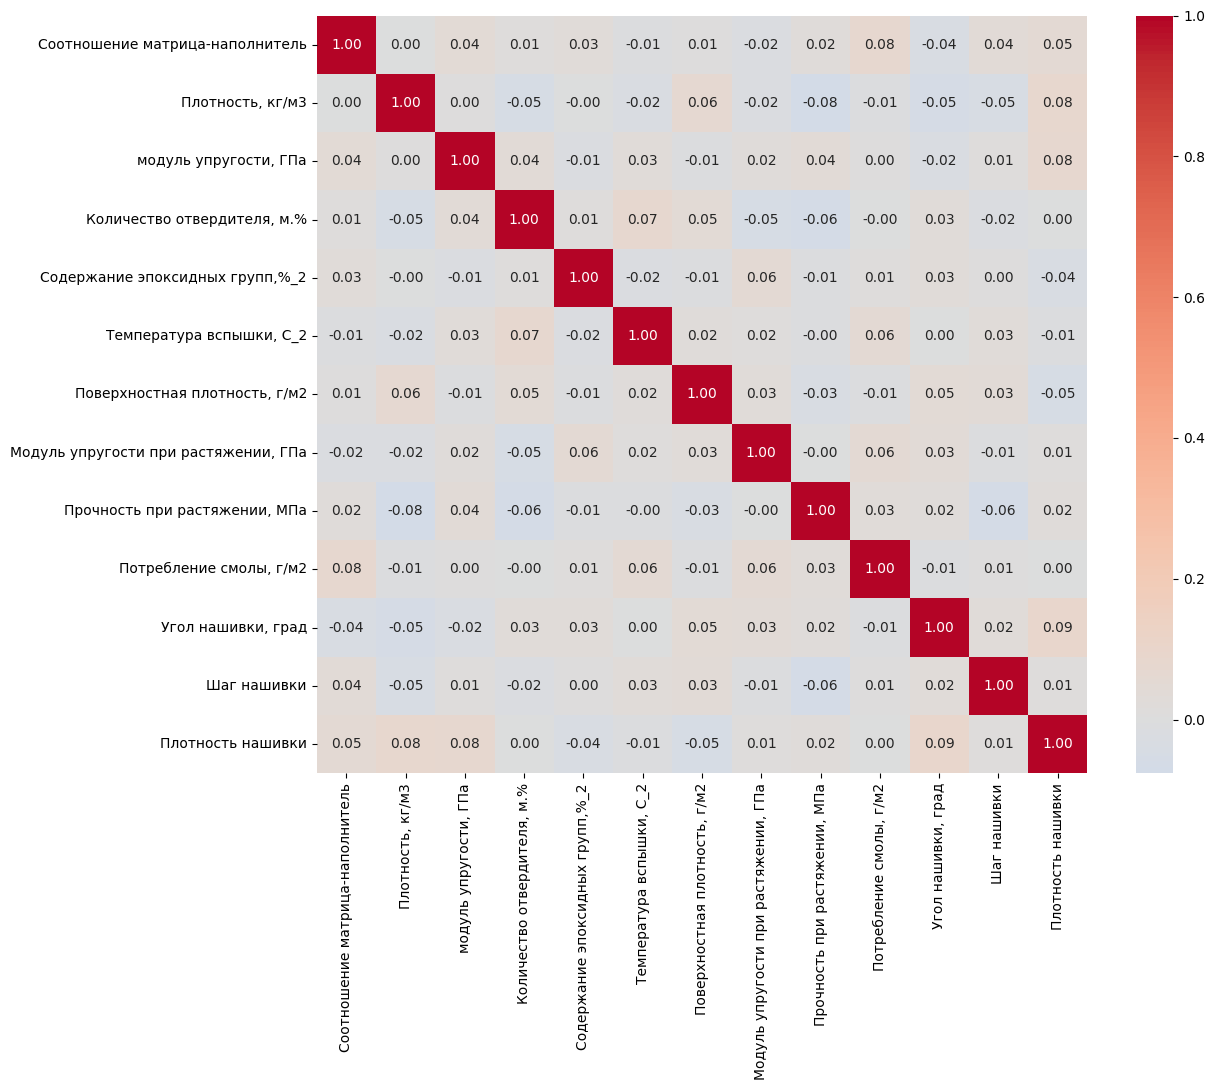

In [14]:
plt.figure(figsize=(13, 11))
sns.heatmap(
    df_clean.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.tight_layout()
plt.show()

После выбранной очистки выраженных парных линейных связей не обнаружено

In [15]:
targets = [
    "Модуль упругости при растяжении, ГПа",
    "Прочность при растяжении, МПа",
    "Соотношение матрица-наполнитель",
]

corr = df_clean.corr()[targets].drop(index=targets[:2])
corr.loc[targets[2], targets[2]] = float("nan")
corr.abs().idxmax(), corr.abs().max()

(Модуль упругости при растяжении, ГПа    Содержание эпоксидных групп,%_2
 Прочность при растяжении, МПа                          Плотность, кг/м3
 Соотношение матрица-наполнитель                 Потребление смолы, г/м2
 dtype: object,
 Модуль упругости при растяжении, ГПа    0.055271
 Прочность при растяжении, МПа           0.076305
 Соотношение матрица-наполнитель         0.075740
 dtype: float64)

| Цель | Признак с максимальным \|r\| | \|r\| |
| :--- | :--- | :--- |
| модуль при растяжении | содержание эпоксидных групп | 0.055 |
| прочность при растяжении | плотность | 0.076 |
| соотношение матрица–наполнитель | потребление смолы  | 0.076  |

На тест оставляем 30% исходных наблюдений. Параметры моделей выбираем на обучающей части с перекрёстной проверкой на 10 блоках. Основная метрика — MAE.

В каждом обучающем блоке отдельно рассчитываем границы IQR и обучаем масштабировщик. Валидационные и тестовые строки не удаляем.

В окончательном расчёте не выбираем параметры по тестовым результатам.

In [16]:
RATIO = "Соотношение матрица-наполнитель"
MODULUS = "Модуль упругости при растяжении, ГПа"
STRENGTH = "Прочность при растяжении, МПа"
ANGLE = "Угол нашивки, град"
RANDOM_STATE = 42
TEST_SIZE = 0.3
IQR_FACTOR = 1.5

FEATURES = [
    RATIO, "Плотность, кг/м3", "модуль упругости, ГПа",
    "Количество отвердителя, м.%", "Содержание эпоксидных групп,%_2",
    "Температура вспышки, С_2", "Поверхностная плотность, г/м2",
    "Потребление смолы, г/м2", ANGLE, "Шаг нашивки", "Плотность нашивки",
]



def iqr_keep_mask(frame: pd.DataFrame) -> pd.Series:
    """Маска 1,5 IQR; передавать только входы обучающей части, без целей."""
    if frame.empty or not frame.index.is_unique:
        raise ValueError("Нужна непустая таблица с уникальным индексом.")
    if not np.isfinite(frame.to_numpy(dtype=float)).all():
        raise ValueError("Входы должны содержать только конечные числа.")
    q1, q3 = frame.quantile(0.25), frame.quantile(0.75)
    spread = q3 - q1
    return ~((frame < q1 - IQR_FACTOR * spread)
             | (frame > q3 + IQR_FACTOR * spread)).any(axis=1)


def split_data(
    data: pd.DataFrame, features: list[str], targets: list[str]
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Разделить исходные строки 70/30 без фильтрации и утечки целей."""
    if not features or not targets or set(features) & set(targets):
        raise ValueError("Нужны непустые непересекающиеся входы и цели.")
    if not data.index.is_unique:
        raise ValueError("Индексы наблюдений должны быть уникальными.")
    x_train, x_test, y_train, y_test = train_test_split(
        data[features], data[targets], test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    return x_train, x_test, y_train, y_test


targets_task1 = [MODULUS, STRENGTH]
X_all, y_all = df[FEATURES], df[targets_task1]
X_train, X_test, y_train, y_test = split_data(df, FEATURES, targets_task1)
X_train_cv, y_train_cv = X_train.copy(), y_train.copy()
train_out = ~iqr_keep_mask(X_train)
X_train, y_train = X_train.loc[~train_out].copy(), y_train.loc[~train_out].copy()
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("столбцов на входе:", X_train.shape[1])
print(X_train.columns.tolist())
print("train / test:", len(X_train), len(X_test))
print("снято из train:", int(train_out.sum()))


столбцов на входе: 11
['Соотношение матрица-наполнитель', 'Плотность, кг/м3', 'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2', 'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']
train / test: 663 307
снято из train: 53


Для прогноза модуля и прочности на вход идут 11 параметров состава и режима. Обе цели из входа исключены: в приложении они заранее неизвестны. Выбросы по IQR сняты только с обучающей выборки и только по признакам.

In [17]:
def choose_params(models: list, X: pd.DataFrame, y: pd.Series) -> tuple:
    blocks = []
    cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

    for train_pos, valid_pos in cv.split(X):
        X_fit, y_fit = X.iloc[train_pos], y.iloc[train_pos]
        keep = iqr_keep_mask(X_fit)

        scaler_cv = MinMaxScaler()
        blocks.append((
            scaler_cv.fit_transform(X_fit.loc[keep]),
            y_fit.loc[keep],
            scaler_cv.transform(X.iloc[valid_pos]),
            y.iloc[valid_pos],
        ))

    selected, rows = {}, []

    for name, model, grid in models:
        best_mae = np.inf

        for params in ParameterGrid(grid):
            errors = []

            for X_fit, y_fit, X_valid, y_valid in blocks:
                candidate = clone(model).set_params(**params)
                candidate.fit(X_fit, y_fit)
                pred = candidate.predict(X_valid)
                errors.append(mean_absolute_error(y_valid, pred))

            mae = np.mean(errors)
            rows.append({
                "Модель": name,
                "Параметры": params,
                "MAE_cv": mae,
                "SD_cv": np.std(errors, ddof=1),
            })

            if mae < best_mae:
                best_mae = mae
                selected[name] = clone(model).set_params(**params)

    return selected, pd.DataFrame(rows).sort_values("MAE_cv")

In [18]:
models = [
    ("Среднее", DummyRegressor(strategy="mean"), {}),
    ("Линейная", LinearRegression(), {}),
    ("Ridge", Ridge(), {
        "alpha": [0.1, 1.0, 10.0, 100.0],
    }),
    ("Случайный лес", RandomForestRegressor(random_state=RANDOM_STATE), {
        "n_estimators": [100, 200],
        "max_depth": [3, None],
        "min_samples_leaf": [1, 10],
    }),
    ("kNN", KNeighborsRegressor(), {
        "n_neighbors": [5, 15, 30],
        "weights": ["uniform", "distance"],
    }),
]

In [19]:
y_train_mod = y_train["Модуль упругости при растяжении, ГПа"]
y_test_mod = y_test["Модуль упругости при растяжении, ГПа"]

models_mod, cv_mod = choose_params(
    models, X_train_cv, y_train_cv[y_train_mod.name]
)

display(cv_mod.round(4))

best_mod_name = cv_mod.loc[
    cv_mod["Модель"].ne("Среднее"), "Модель"
].iloc[0]

print("Выбрана среди моделей с признаками:", best_mod_name)

,Модель,Параметры,MAE_cv,SD_cv
0,Среднее,{},2.4831,0.1991
5,Ridge,{'alpha': 100.0},2.4877,0.1943
9,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 10, 'n_es...",2.4957,0.1807
7,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",2.4970,0.1854
6,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",2.4988,0.1809
4,Ridge,{'alpha': 10.0},2.4995,0.1923
8,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 10, 'n_es...",2.5015,0.1785
3,Ridge,{'alpha': 1.0},2.5091,0.1936
2,Ridge,{'alpha': 0.1},2.5108,0.1937
1,Линейная,{},2.5110,0.1937


Выбрана среди моделей с признаками: Ridge


Для модуля упругости среди моделей, использующих признаки, выбран Ridge с alpha=100. Средняя MAE на 10 блоках составила 2.4877 ГПа против 2.4831 ГПа у среднего. По перекрёстной проверке преимущество перед базовым прогнозом не получено. Окончательные ошибки train и test сравним после обучения выбранных конфигураций.

In [20]:
y_train_str = y_train["Прочность при растяжении, МПа"]
y_test_str = y_test["Прочность при растяжении, МПа"]

models_str, cv_str = choose_params(
    models, X_train_cv, y_train_cv[y_train_str.name]
)

display(cv_str.round(4))

best_str_name = cv_str.loc[
    cv_str["Модель"].ne("Среднее"), "Модель"
].iloc[0]

print("Выбрана среди моделей с признаками:", best_str_name)

,Модель,Параметры,MAE_cv,SD_cv
0,Среднее,{},384.6932,23.7544
5,Ridge,{'alpha': 100.0},384.9543,23.3473
7,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",386.1773,24.4497
4,Ridge,{'alpha': 10.0},386.3370,22.6496
6,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",386.6156,24.4853
3,Ridge,{'alpha': 1.0},388.2632,22.5305
9,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 10, 'n_es...",388.3988,24.2915
8,Случайный лес,"{'max_depth': 3, 'min_samples_leaf': 10, 'n_es...",388.4677,24.5006
2,Ridge,{'alpha': 0.1},388.5964,22.5480
1,Линейная,{},388.6357,22.5504


Выбрана среди моделей с признаками: Ridge


Для каждой модели выбраны параметры с минимальной средней MAE на 10 блоках. SD_cv показывает разброс ошибок между блоками, а не доверительный интервал.

Среднее оставляем как базовый прогноз. Отдельно выбираем модель, использующую входные признаки, для демонстрации прогнозирования. Это не означает, что она обязательно лучше среднего.

In [21]:
target_ratio = RATIO
features_ratio = [name for name in FEATURES if name != RATIO]
X_all_r, y_all_r = df[features_ratio], df[RATIO]
X_train_r, X_test_r, y_train_frame, y_test_frame = split_data(df, features_ratio, [RATIO])
y_train_r, y_test_r = y_train_frame[RATIO], y_test_frame[RATIO]
X_train_r_cv, y_train_r_cv = X_train_r.copy(), y_train_r.copy()
train_out_r = ~iqr_keep_mask(X_train_r)
X_train_r = X_train_r.loc[~train_out_r].copy()
y_train_r = y_train_r.loc[~train_out_r].copy()
scaler_r = MinMaxScaler()
X_train_r_s = scaler_r.fit_transform(X_train_r)
X_test_r_s = scaler_r.transform(X_test_r)
print("столбцов:", X_train_r.shape[1])
print(X_train_r.columns.tolist())
print("train / test:", len(X_train_r), len(X_test_r))
print("снято из train:", int(train_out_r.sum()))


столбцов: 10
['Плотность, кг/м3', 'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2', 'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']
train / test: 667 307
снято из train: 49


Для прогноза соотношения матрица–наполнитель используем 10 признаков. Само соотношение и обе механические характеристики исключаем из входа.

Проверяем две архитектуры нейросети и два значения регуляризации. Выбираем вариант по средней MAE на перекрёстной проверке, а не по тестовой ошибке.

In [22]:
models_nn = [
    ("Среднее", DummyRegressor(strategy="mean"), {}),
    ("Сеть 64, 32", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=3000,
        random_state=RANDOM_STATE,
    ), {"alpha": [0.0001, 1.0]}),
    ("Сеть 16", MLPRegressor(
        hidden_layer_sizes=(16,),
        max_iter=3000,
        random_state=RANDOM_STATE,
    ), {"alpha": [0.0001, 1.0]}),
]

models_r, cv_r = choose_params(
    models_nn, X_train_r_cv, y_train_r_cv
)

display(cv_r.round(4))

best_nn_name = cv_r.loc[
    cv_r["Модель"].ne("Среднее"), "Модель"
].iloc[0]

print("Выбрана нейросеть:", best_nn_name)

,Модель,Параметры,MAE_cv,SD_cv
0,Среднее,{},0.7196,0.0968
4,Сеть 16,{'alpha': 1.0},0.7433,0.1118
3,Сеть 16,{'alpha': 0.0001},0.7457,0.1153
2,"Сеть 64, 32",{'alpha': 1.0},0.7458,0.1043
1,"Сеть 64, 32",{'alpha': 0.0001},0.8359,0.1369


Выбрана нейросеть: Сеть 16


Среди рассмотренных сетей по средней MAE на 10 блоках выбрана сеть с 16 нейронами и alpha=1. Её MAE составила 0.7433, у сети с двумя скрытыми слоями и alpha=1 — 0.7458. Базовый прогноз по среднему показал меньшую ошибку — 0.7196. Преимущество нейросетевого прогноза на перекрёстной проверке не получено.

In [23]:
tasks = [
    ("Модуль, ГПа", models_mod,
     X_train_s, y_train_mod, X_test_s, y_test_mod),

    ("Прочность, МПа", models_str,
     X_train_s, y_train_str, X_test_s, y_test_str),

    ("Соотношение", models_r,
     X_train_r_s, y_train_r, X_test_r_s, y_test_r),
]

rows = []

for target, fitted_models, Xtr, ytr, Xte, yte in tasks:
    for name, model in fitted_models.items():
        model.fit(Xtr, ytr)

        for sample, X_part, y_part in [
            ("train", Xtr, ytr),
            ("test", Xte, yte),
        ]:
            pred = model.predict(X_part)

            rows.append({
                "Цель": target,
                "Модель": name,
                "Выборка": sample,
                "MAE": mean_absolute_error(y_part, pred),
                "RMSE": mean_squared_error(y_part, pred) ** 0.5,
                "R2": r2_score(y_part, pred),
            })

results = pd.DataFrame(rows)

for target in results["Цель"].unique():
    print(target)
    display(
        results.loc[results["Цель"].eq(target)]
        .drop(columns="Цель")
        .round(4)
    )

Модуль, ГПа


,Модель,Выборка,MAE,RMSE,R2
0,Среднее,train,2.4306,3.0395,0.0000
1,Среднее,test,2.5605,3.1833,-0.0200
2,Линейная,train,2.4177,3.0065,0.0216
3,Линейная,test,2.5691,3.1949,-0.0275
4,Ridge,train,2.4249,3.0268,0.0083
5,Ridge,test,2.5604,3.1815,-0.0189
6,Случайный лес,train,2.2827,2.8605,0.1143
7,Случайный лес,test,2.5900,3.2187,-0.0428
8,kNN,train,0.0000,0.0000,1.0000
9,kNN,test,2.5908,3.2432,-0.0588


Прочность, МПа


,Модель,Выборка,MAE,RMSE,R2
10,Среднее,train,382.8097,490.0073,0.0000
11,Среднее,test,378.9462,473.2519,-0.0001
12,Линейная,train,381.0056,485.0540,0.0201
13,Линейная,test,378.5736,472.0605,0.0049
14,Ridge,train,381.7516,488.2270,0.0073
15,Ridge,test,378.7745,472.6075,0.0026
16,Случайный лес,train,362.2159,458.8249,0.1232
17,Случайный лес,test,379.0778,471.2613,0.0083
18,kNN,train,374.9145,477.7960,0.0492
19,kNN,test,381.5281,480.8073,-0.0323


Соотношение


,Модель,Выборка,MAE,RMSE,R2
20,Среднее,train,0.7122,0.8970,0.0000
21,Среднее,test,0.7523,0.9261,-0.0006
22,"Сеть 64, 32",train,0.6949,0.8765,0.0453
23,"Сеть 64, 32",test,0.7675,0.9405,-0.0319
24,Сеть 16,train,0.7046,0.8893,0.0172
25,Сеть 16,test,0.7727,0.9457,-0.0435


Ошибки train рассчитаны на строках, оставшихся после IQR-очистки. Для каждой задачи все модели обучаются и проверяются на одинаковых наборах строк.

Тестовая часть остаётся без удаления наблюдений. Параметры всех моделей выбраны до расчёта этих тестовых ошибок.

Механические свойства


,min до,max до,min после,max после
Соотношение матрица-наполнитель,0.5474,5.2958,0.0,1.0
"Плотность, кг/м3",1784.4822,2160.7514,0.0,1.0
"модуль упругости, ГПа",2.4369,1572.0960,0.0,1.0
"Количество отвердителя, м.%",38.6685,181.8284,0.0,1.0
"Содержание эпоксидных групп,%_2",15.6959,28.9551,0.0,1.0
"Температура вспышки, С_2",179.3744,386.0680,0.0,1.0
"Поверхностная плотность, г/м2",0.6037,1291.3401,0.0,1.0
"Потребление смолы, г/м2",75.8318,359.0522,0.0,1.0
"Угол нашивки, град",0.0000,90.0000,0.0,1.0
Шаг нашивки,0.1450,13.4849,0.0,1.0


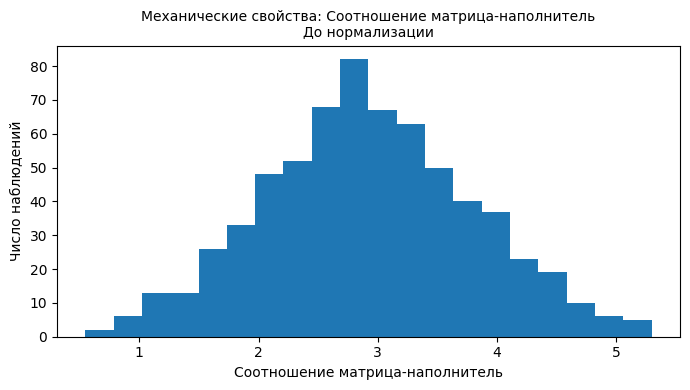

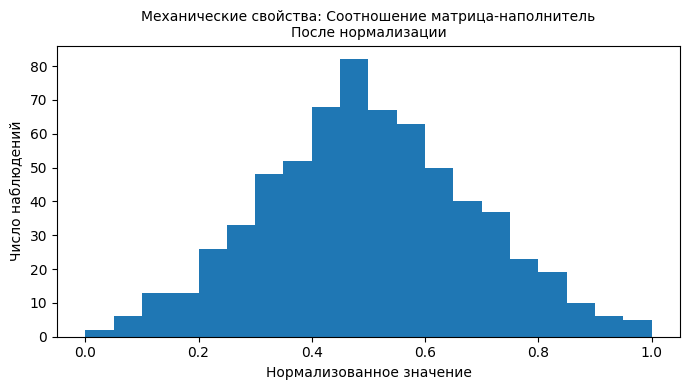

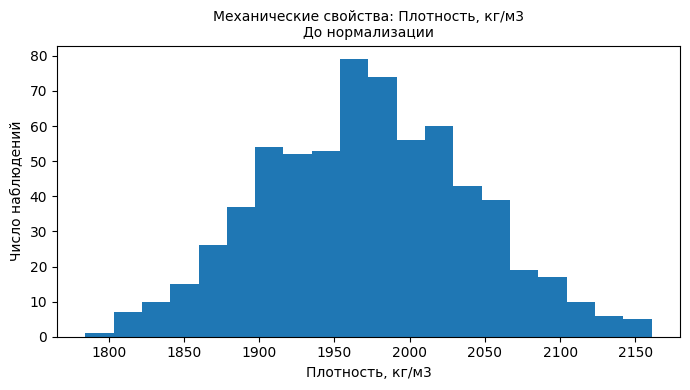

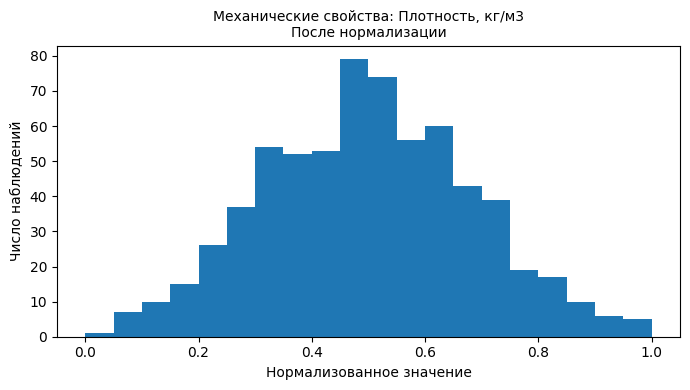

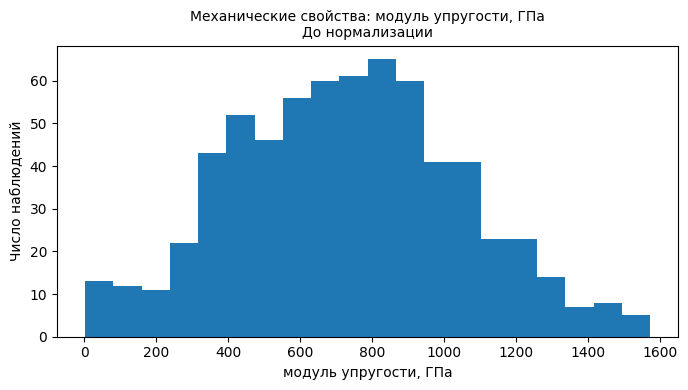

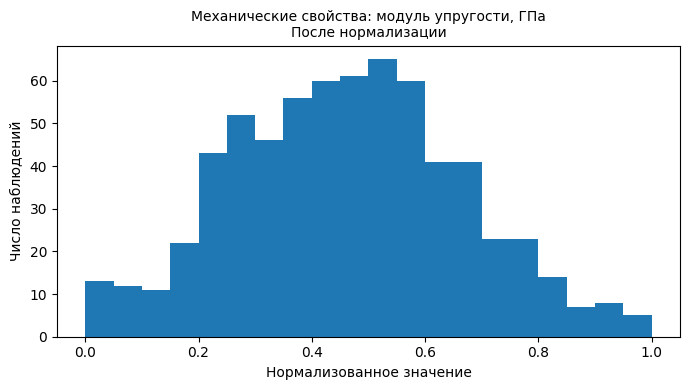

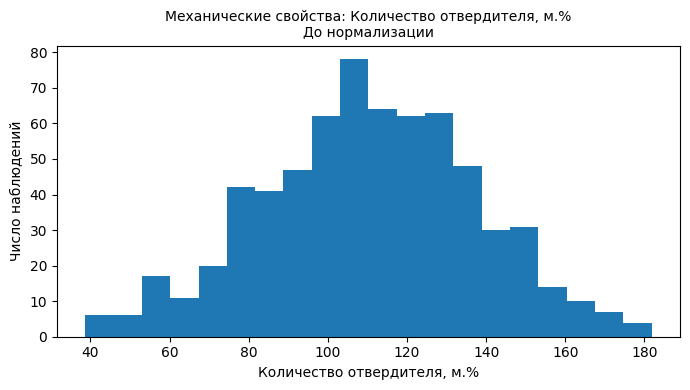

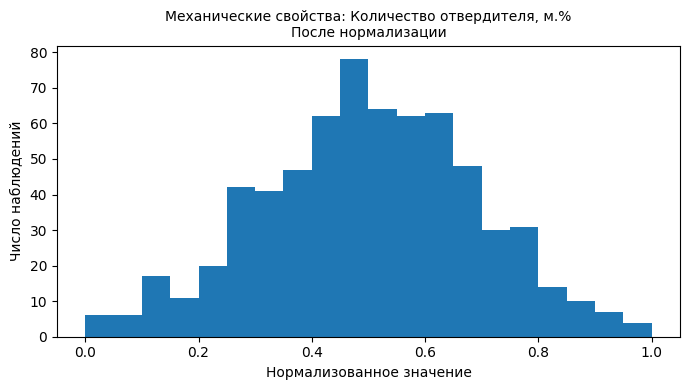

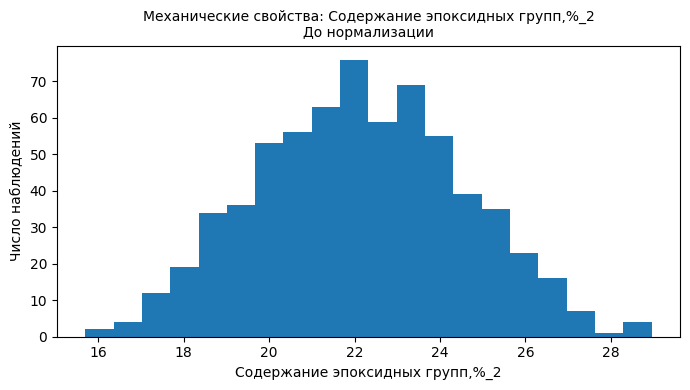

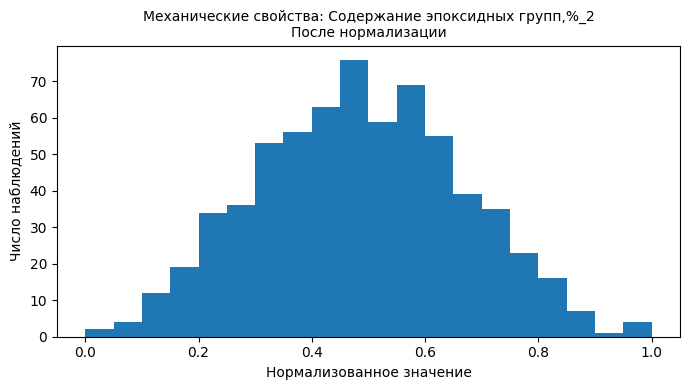

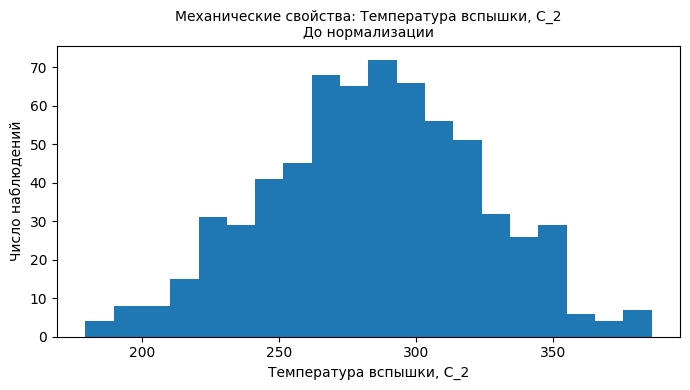

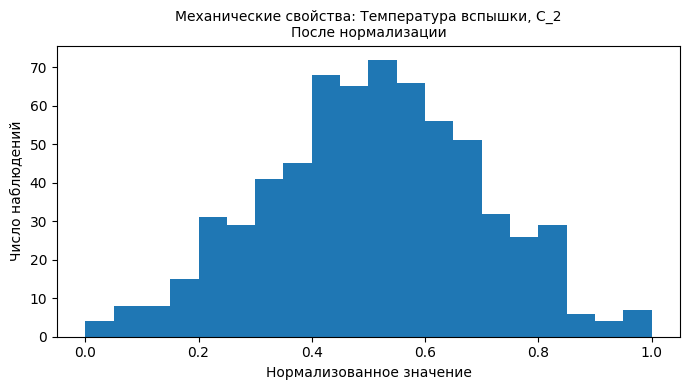

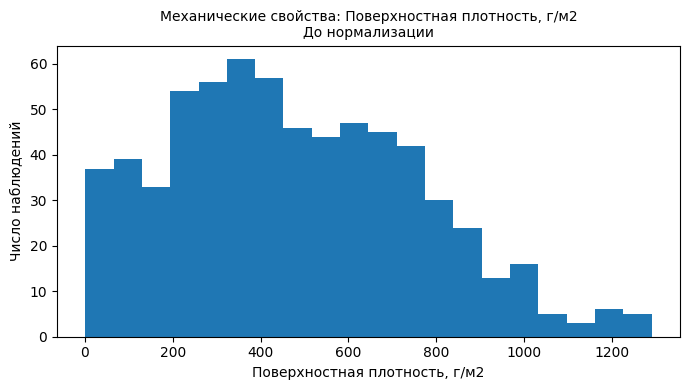

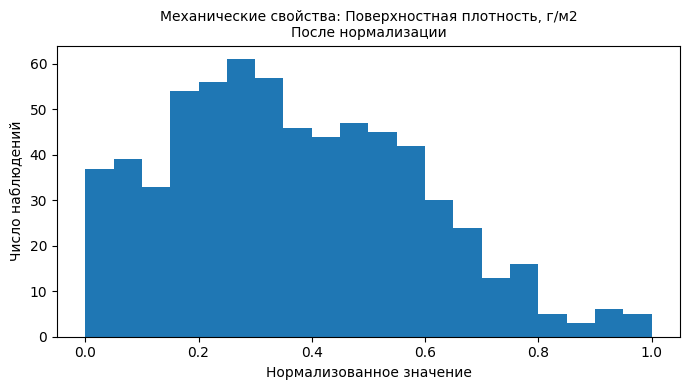

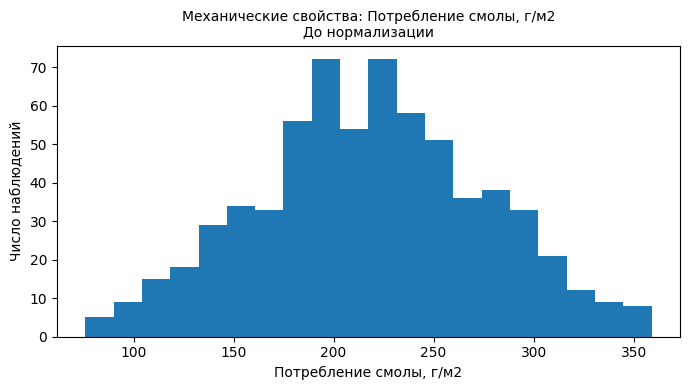

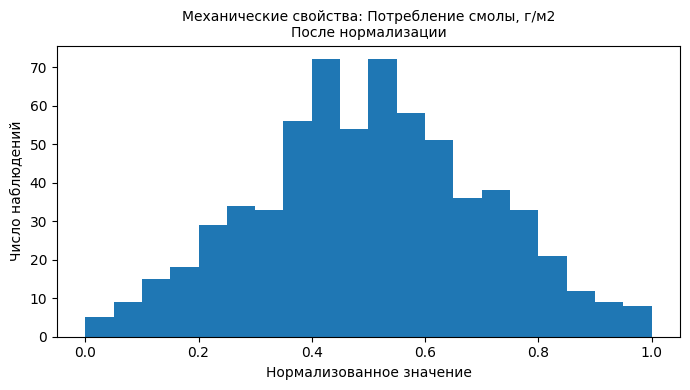

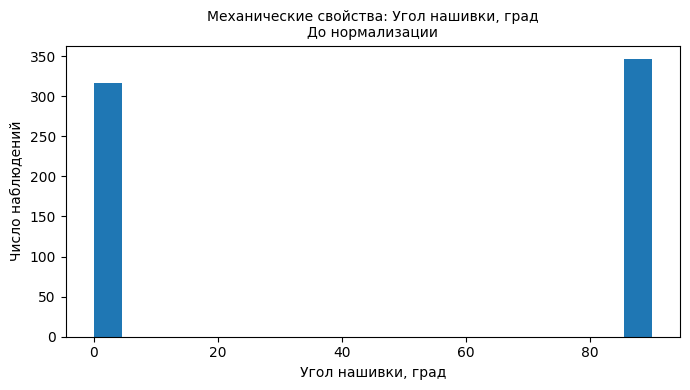

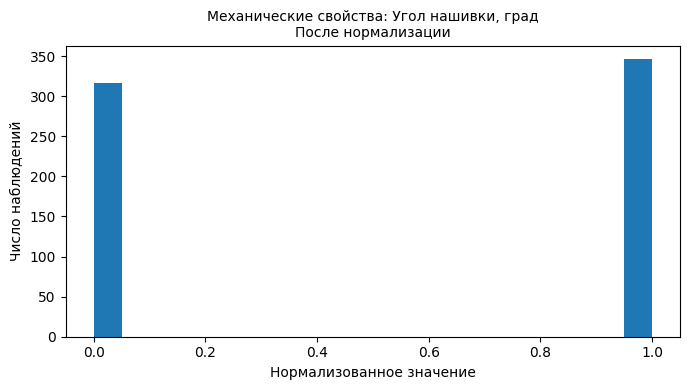

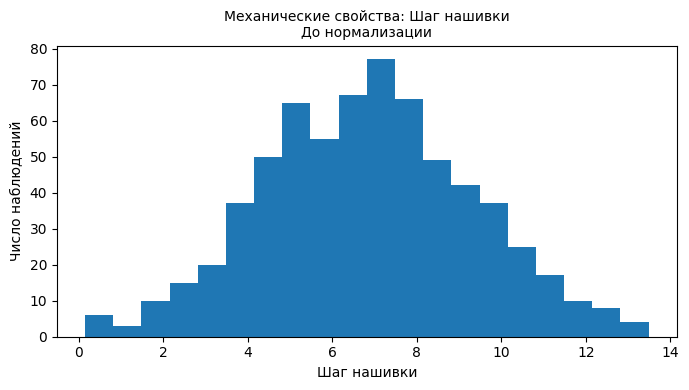

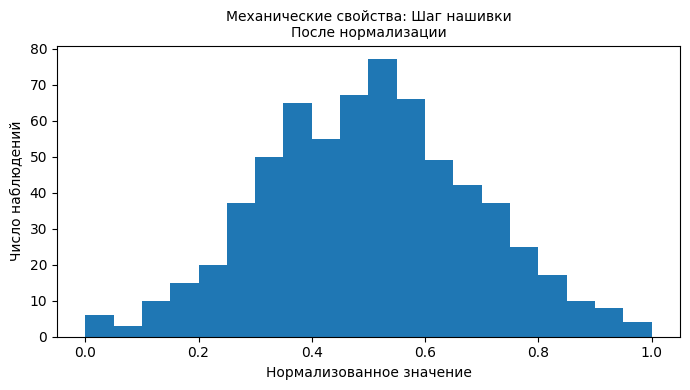

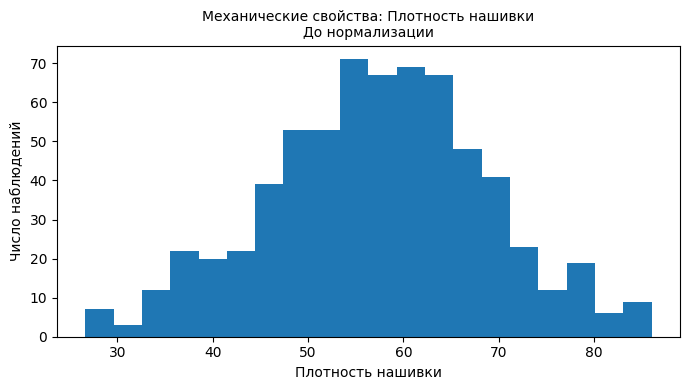

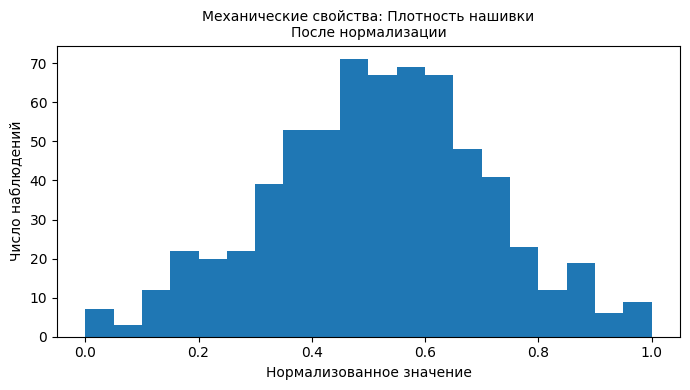

Соотношение


,min до,max до,min после,max после
"Плотность, кг/м3",1784.4822,2160.7514,0.0,1.0
"модуль упругости, ГПа",2.4369,1572.0960,0.0,1.0
"Количество отвердителя, м.%",38.6685,181.8284,0.0,1.0
"Содержание эпоксидных групп,%_2",15.6959,28.9551,0.0,1.0
"Температура вспышки, С_2",179.3744,386.0680,0.0,1.0
"Поверхностная плотность, г/м2",0.6037,1291.3401,0.0,1.0
"Потребление смолы, г/м2",75.8318,359.0522,0.0,1.0
"Угол нашивки, град",0.0000,90.0000,0.0,1.0
Шаг нашивки,0.1450,13.4849,0.0,1.0
Плотность нашивки,26.6472,86.0124,0.0,1.0


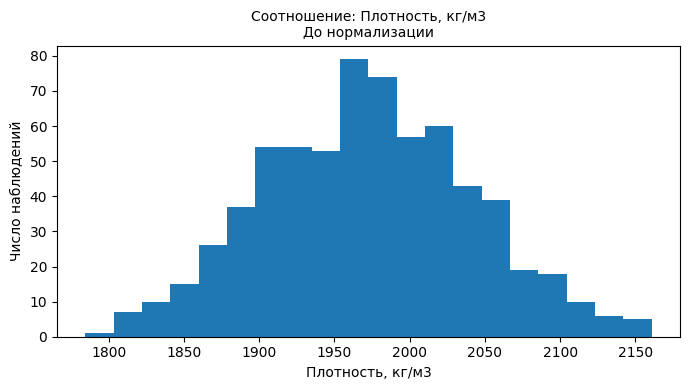

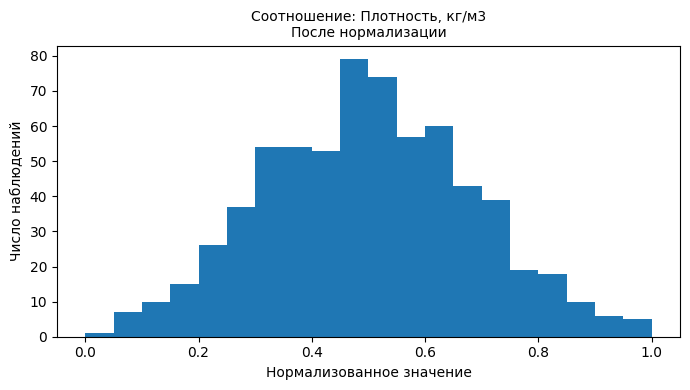

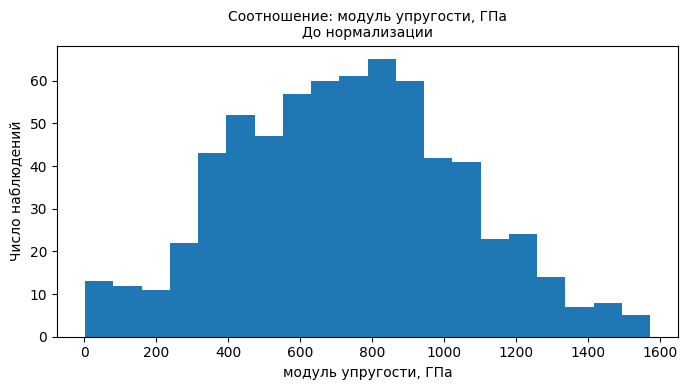

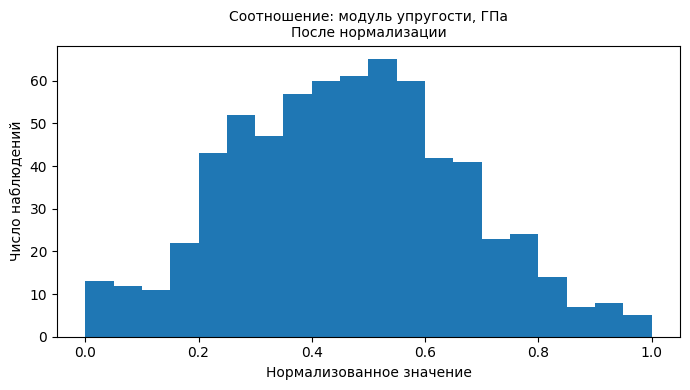

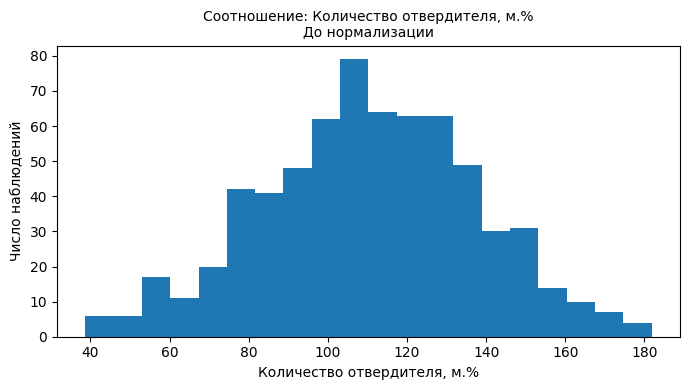

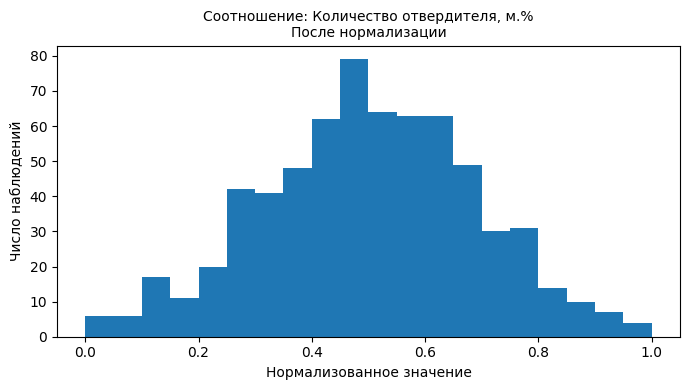

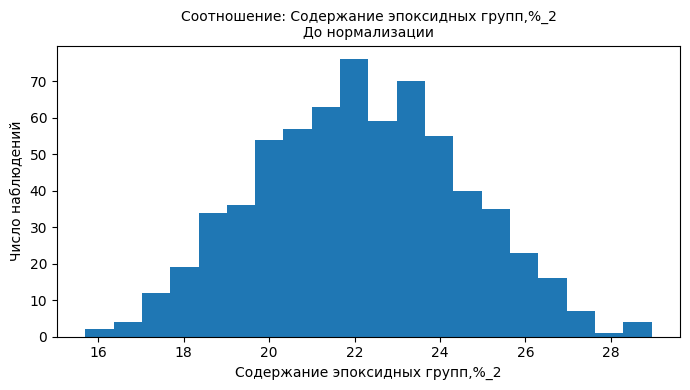

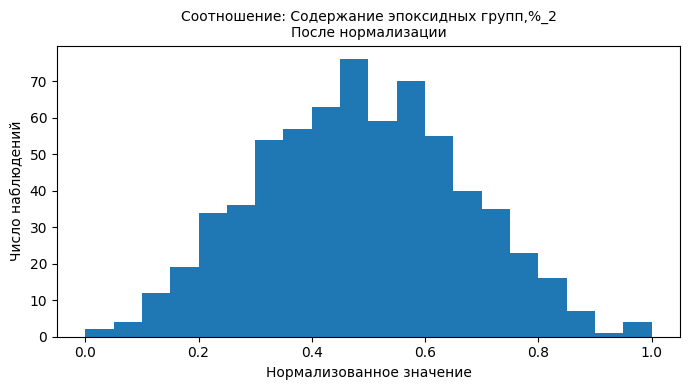

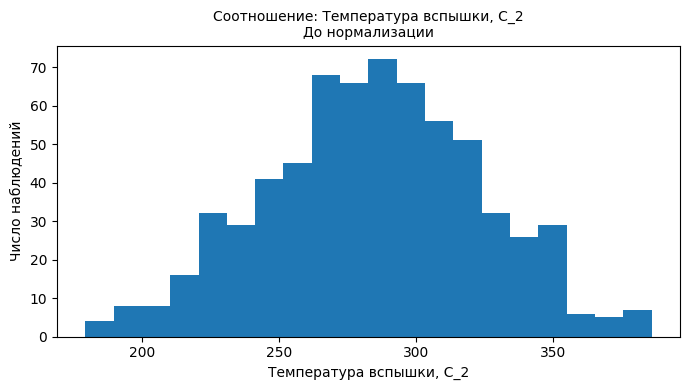

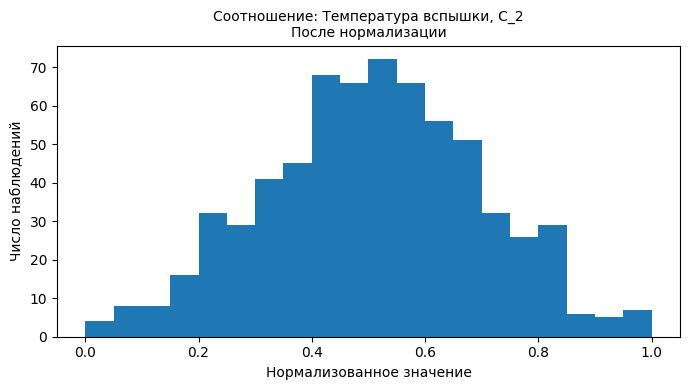

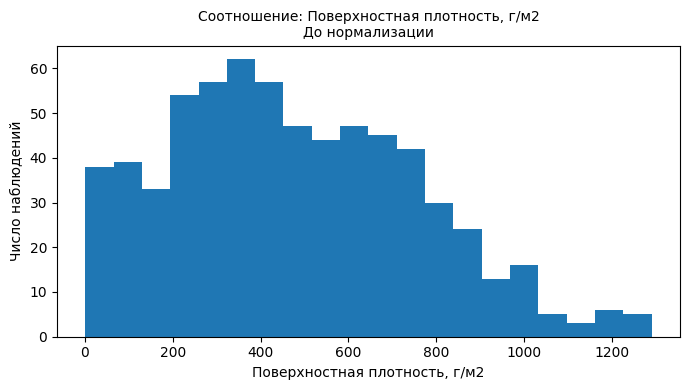

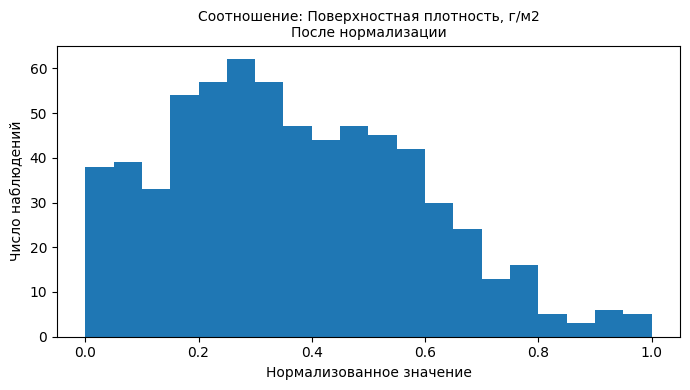

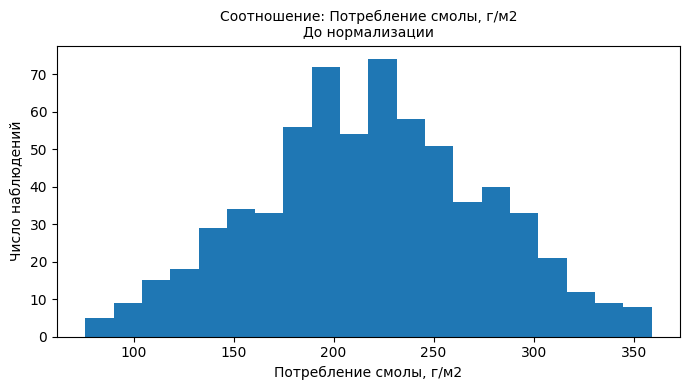

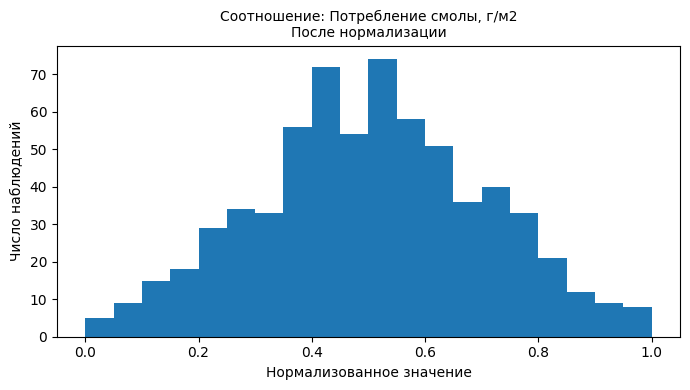

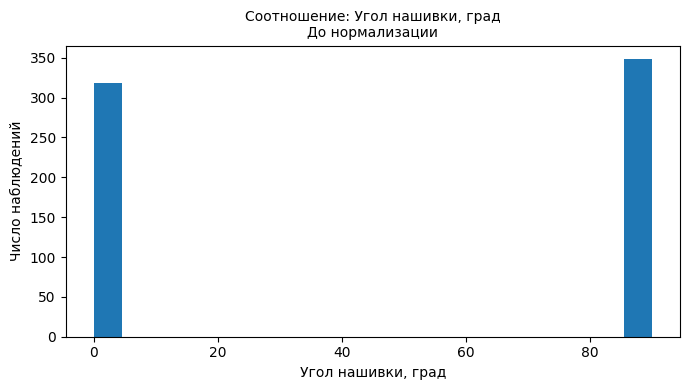

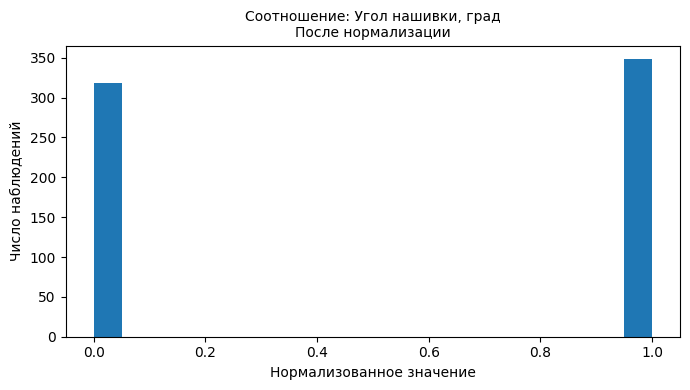

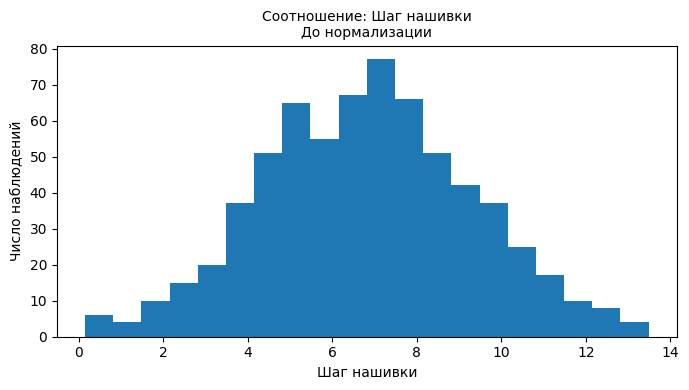

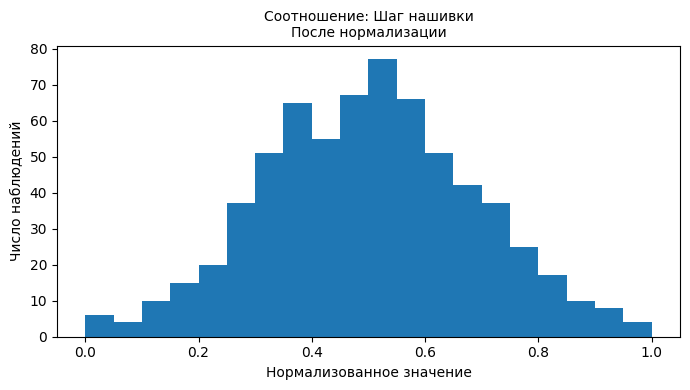

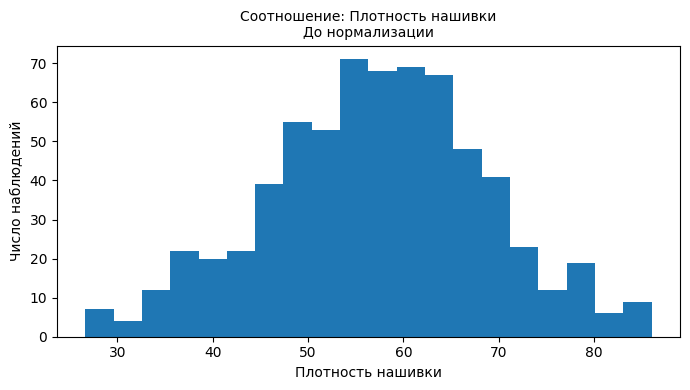

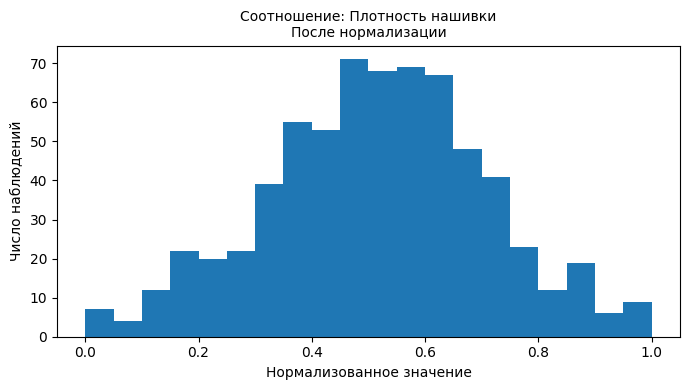

In [24]:
for task, original, scaled in [
    ("Механические свойства", X_train, X_train_s),
    ("Соотношение", X_train_r, X_train_r_s),
]:
    normalized = pd.DataFrame(
        scaled, index=original.index, columns=original.columns
    )

    print(task)
    display(pd.DataFrame({
        "min до": original.min(),
        "max до": original.max(),
        "min после": normalized.min(),
        "max после": normalized.max(),
    }).round(4))

    for col in original.columns:
        for stage, values in [
            ("До нормализации", original[col]),
            ("После нормализации", normalized[col]),
        ]:
            plt.figure(figsize=(7, 4))
            plt.hist(values, bins=20)
            plt.title(f"{task}: {col}\n{stage}", fontsize=10)
            plt.xlabel(
                col if stage == "До нормализации"
                else "Нормализованное значение"
            )
            plt.ylabel("Число наблюдений")
            plt.tight_layout()
            plt.show()
            plt.close()

Архитектура: (10, 16, 1)
Активация скрытых слоёв: relu
Активация выхода: identity
Оптимизатор: adam
Регуляризация alpha: 1.0
Выполнено итераций: 543


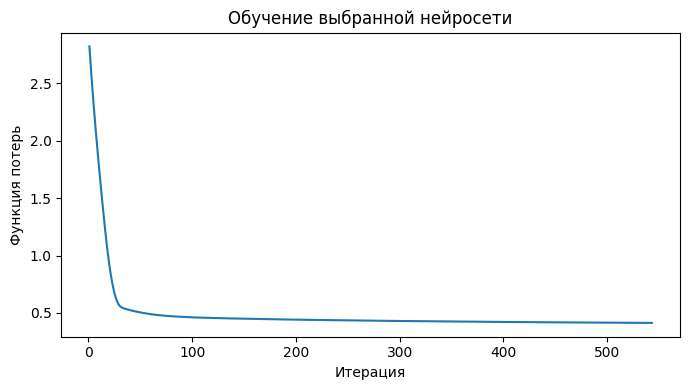

In [25]:
nn = models_r[best_nn_name]

print("Архитектура:", (X_train_r.shape[1], *nn.hidden_layer_sizes, 1))
print("Активация скрытых слоёв:", nn.activation)
print("Активация выхода:", nn.out_activation_)
print("Оптимизатор:", nn.solver)
print("Регуляризация alpha:", nn.alpha)
print("Выполнено итераций:", nn.n_iter_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(nn.loss_curve_) + 1), nn.loss_curve_)
plt.xlabel("Итерация")
plt.ylabel("Функция потерь")
plt.title("Обучение выбранной нейросети")
plt.tight_layout()
plt.show()
plt.close()

На графике показана функция потерь при обучении выбранной сети, а не MAE тестовой выборки.

Нейросеть оценивает соотношение по имеющимся признакам. Полученный прогноз не является доказанно оптимальной рецептурой и не гарантирует достижение определённых механических свойств.

In [26]:
saved_models = {
    "Модуль, ГПа": Pipeline([
        ("scaler", scaler),
        ("model", models_mod[best_mod_name]),
    ]),
    "Прочность, МПа": Pipeline([
        ("scaler", scaler),
        ("model", models_str[best_str_name]),
    ]),
    "Соотношение": Pipeline([
        ("scaler", scaler_r),
        ("model", nn),
    ]),
}

for target, example in [
    ("Модуль, ГПа", X_test.iloc[[0]]),
    ("Прочность, МПа", X_test.iloc[[0]]),
    ("Соотношение", X_test_r.iloc[[0]]),
]:
    prediction = saved_models[target].predict(example)[0]
    print(target, ":", round(float(prediction), 4))

Модуль, ГПа : 73.1867
Прочность, МПа : 2481.4292
Соотношение : 2.7873


Для прогноза модуля и прочности сравнили линейную регрессию, Ridge, случайный лес и kNN. Среднее обучающей выборки использовали как базовый прогноз.

Среди моделей, использующих признаки, по средней MAE на 10 блоках выбран Ridge с alpha=100 для обеих механических характеристик. При этом его средняя ошибка на перекрёстной проверке немного выше ошибки базового прогноза. Небольшие различия на тесте не дают основания утверждать устойчивое преимущество модели.

Для прогноза соотношения выбрана нейросеть с одним скрытым слоем из 16 нейронов и alpha=1. Она показала меньшую среднюю ошибку на перекрёстной проверке среди рассмотренных сетей, но не улучшила результат относительно среднего. Поэтому преимущество нейросетевого прогноза на этих данных не подтверждено.

Для всех моделей рассчитаны ошибки на обучающей и тестовой частях. Выбранные модели объединены с масштабировщиками, получение прогноза проверено. Следующая ячейка сохраняет эти модели в файл для веб-приложения.

Результаты относятся к этому набору данных и выбранной схеме обработки. Полученные модели подходят для учебной демонстрации, но их качество не подтверждает готовность к производственному применению.

## Рисунки и таблицы итогового расчёта

Модуль `report_figures.py` строит рисунки 1–4, 6–17 и 19 непосредственно по данным, масштабировщикам и моделям этого запуска. Эти PNG используются в записке и презентации без дополнительной ручной отрисовки. Файл `figures/manifest.json` связывает номера рисунков с их файлами и контрольными суммами. Схемы 5 и 18 и снимки интерфейса 20–21 оформлены отдельно.

In [27]:
from report_figures import export_report_figures

report_images = export_report_figures(
    data=df, descriptive_clean=df_clean,
    training_properties=X_train, normalized_properties=X_train_s,
    training_ratio=X_train_r, normalized_ratio=X_train_r_s,
    test_features=X_test, test_targets=y_test,
    pipelines=saved_models, network=nn,
)
for number, filename in report_images.items():
    print(f"Рисунок {number}: {filename}")
results.to_csv(RESULTS_DIR / "metrics.csv", index=False, encoding="utf-8-sig")
for name, table in [("cv_modulus", cv_mod), ("cv_strength", cv_str), ("cv_ratio", cv_r)]:
    table.to_csv(RESULTS_DIR / f"{name}.csv", index=False, encoding="utf-8-sig")
print("Таблицы итогового расчёта сохранены в results/.")

Рисунок 1: figures/figure_01.png
Рисунок 2: figures/figure_02.png
Рисунок 3: figures/figure_03.png
Рисунок 4: figures/figure_04.png
Рисунок 6: figures/figure_06.png
Рисунок 7: figures/figure_07.png
Рисунок 8: figures/figure_08.png
Рисунок 9: figures/figure_09.png
Рисунок 10: figures/figure_10.png
Рисунок 11: figures/figure_11.png
Рисунок 12: figures/figure_12.png
Рисунок 13: figures/figure_13.png
Рисунок 14: figures/figure_14.png
Рисунок 15: figures/figure_15.png
Рисунок 16: figures/figure_16.png
Рисунок 17: figures/figure_17.png
Рисунок 19: figures/figure_19.png
Таблицы итогового расчёта сохранены в results/.


## Сохранение моделей для приложения

Выбранные модели вместе с масштабировщиками сохраняются в `models.joblib`. Демонстрационные значения из обучающей строки 604 записываются в `examples.json`. Веб-приложение `app.py` загружает модели через `PredictionService`, проверяет ввод и использует порядок признаков сохранённых конвейеров. Диапазоны предупреждений берутся из обученных масштабировщиков; значения не обрезаются. Повторного обучения в приложении нет.


In [28]:
import json
import joblib

model_bundle = {
    "properties": {
        "title": "Модуль и прочность",
        "features": FEATURES,
        "models": {
            MODULUS: saved_models["Модуль, ГПа"],
            STRENGTH: saved_models["Прочность, МПа"],
        },
    },
    "ratio": {
        "title": "Соотношение матрица-наполнитель",
        "features": features_ratio,
        "models": {RATIO: saved_models["Соотношение"]},
    },
}

for task_data in model_bundle.values():
    task_data["environment"] = run_environment

joblib.dump(model_bundle, "models.joblib", compress=3)
print("Модели сохранены в models.joblib")


example_index = 604
assert example_index in X_train.index and example_index in X_train_r.index
examples = {
    "source": "X_bp.xlsx INNER X_nup.xlsx; обучающая строка с индексом 604",
    "properties": {name: float(df.loc[example_index, name]) for name in FEATURES},
    "ratio": {name: float(df.loc[example_index, name]) for name in features_ratio},
}
with open("examples.json", "w", encoding="utf-8") as file:
    json.dump(examples, file, ensure_ascii=False, indent=2)
    file.write("\n")
print("Обучающий пример сохранён в examples.json")


Модели сохранены в models.joblib
Обучающий пример сохранён в examples.json
